In [68]:
# ============================================================
# Inventory / Product Data Analysis
# Expert Business + Data Science Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [69]:
# ============================================================
# 1. Load Dataset
# ============================================================

file_path = "/content/hardwareStore.csv"
df = pd.read_csv(file_path)

# Preview
print("Shape:", df.shape)
display(df.head())

Shape: (1112, 22)


,CATEGORY_ID,CATEGORY_NAME,PRODUCT_ID,PRODUCT_NAME,DESCRIPTION,DESCRIPTION - Detail 1,DESCRIPTION - Detail 2,DESCRIPTION - Detail 3,DESCRIPTION - Detail 4,STANDARD_COST,...,REGION_ID,LOCATION_ID,WAREHOUSE_ID,QUANTITY,WAREHOUSE_NAME,ADDRESS,POSTAL_CODE,CITY,STATE,COUNTRY_NAME
0,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,3,11,8,50,Beijing,40-5-12 Laogianggen,190518,Beijing,Shenzhen,China
1,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,3,12,9,36,Bombay,1298 Vileparle (E),490231,Bombay,Maharashtra,India
2,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,2,6,2,97,San Francisco,2011 Interiors Blvd,99236,South San Francisco,California,United States of America
3,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,2,8,4,67,"Seattle, Washington",2004 Charade Rd,98199,Seattle,Washington,United States of America
4,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,3,13,6,30,Sydney,12-98 Victoria Street,2901,Sydney,New South Wales,Australia


In [70]:
# ============================================================
# 2. Clean Column Names
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['CATEGORY_ID', 'CATEGORY_NAME', 'PRODUCT_ID', 'PRODUCT_NAME',
       'DESCRIPTION', 'DESCRIPTION_-_DETAIL_1', 'DESCRIPTION_-_DETAIL_2',
       'DESCRIPTION_-_DETAIL_3', 'DESCRIPTION_-_DETAIL_4', 'STANDARD_COST',
       'LIST_PRICE', 'COUNTRY_ID', 'REGION_ID', 'LOCATION_ID', 'WAREHOUSE_ID',
       'QUANTITY', 'WAREHOUSE_NAME', 'ADDRESS', 'POSTAL_CODE', 'CITY', 'STATE',
       'COUNTRY_NAME'],
      dtype='object')


In [71]:

# ============================================================
# 3. Basic Data Understanding
# ============================================================

print(df.info())
display(df.describe(include="all"))
display(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1112 entries, 0 to 1111
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CATEGORY_ID             1112 non-null   int64  
 1   CATEGORY_NAME           1112 non-null   object 
 2   PRODUCT_ID              1112 non-null   int64  
 3   PRODUCT_NAME            1112 non-null   object 
 4   DESCRIPTION             1112 non-null   object 
 5   DESCRIPTION_-_DETAIL_1  1112 non-null   object 
 6   DESCRIPTION_-_DETAIL_2  1112 non-null   object 
 7   DESCRIPTION_-_DETAIL_3  794 non-null    object 
 8   DESCRIPTION_-_DETAIL_4  350 non-null    object 
 9   STANDARD_COST           1112 non-null   float64
 10  LIST_PRICE              1112 non-null   float64
 11  COUNTRY_ID              1112 non-null   object 
 12  REGION_ID               1112 non-null   int64  
 13  LOCATION_ID             1112 non-null   int64  
 14  WAREHOUSE_ID            1112 non-null   

,CATEGORY_ID,CATEGORY_NAME,PRODUCT_ID,PRODUCT_NAME,DESCRIPTION,DESCRIPTION_-_DETAIL_1,DESCRIPTION_-_DETAIL_2,DESCRIPTION_-_DETAIL_3,DESCRIPTION_-_DETAIL_4,STANDARD_COST,...,REGION_ID,LOCATION_ID,WAREHOUSE_ID,QUANTITY,WAREHOUSE_NAME,ADDRESS,POSTAL_CODE,CITY,STATE,COUNTRY_NAME
count,1112.000000,1112,1112.000000,1112,1112,1112,1112,794,350,1112.000000,...,1112.000000,1112.000000,1112.000000,1112.000000,1112,1112,1112,1112,1112,1112
unique,NaN,4,NaN,173,160,87,52,49,16,NaN,...,NaN,NaN,NaN,NaN,9,9,9,9,9,6
top,NaN,Storage,NaN,G.Skill Ripjaws V Series,"Chipset:GeForce GTX 1080 Ti,Memory:11GBCore Cl...",Chipset:GeForce GTX 1080 Ti,Type:288-pin DIMM,RAM Slots:4,Cache:N/A,NaN,...,NaN,NaN,NaN,NaN,Sydney,12-98 Victoria Street,2901,Sydney,New South Wales,United States of America
freq,NaN,416,NaN,58,36,141,197,78,102,NaN,...,NaN,NaN,NaN,NaN,208,208,208,208,208,370
mean,3.203237,NaN,139.579137,NaN,NaN,NaN,NaN,NaN,NaN,765.520405,...,2.469424,10.971223,5.548561,107.474820,NaN,NaN,NaN,NaN,NaN,NaN
std,1.637782,NaN,84.840057,NaN,NaN,NaN,NaN,NaN,NaN,794.252142,...,0.499289,4.662225,2.416821,68.008413,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,12.630000,...,2.000000,5.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.000000,NaN,71.750000,NaN,NaN,NaN,NaN,NaN,NaN,332.380000,...,2.000000,8.000000,4.000000,50.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.000000,NaN,133.000000,NaN,NaN,NaN,NaN,NaN,NaN,582.020000,...,2.000000,11.000000,6.000000,98.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,5.000000,NaN,216.000000,NaN,NaN,NaN,NaN,NaN,NaN,799.050000,...,3.000000,13.000000,8.000000,163.000000,NaN,NaN,NaN,NaN,NaN,NaN


,0
CATEGORY_ID,0
CATEGORY_NAME,0
PRODUCT_ID,0
PRODUCT_NAME,0
DESCRIPTION,0
DESCRIPTION_-_DETAIL_1,0
DESCRIPTION_-_DETAIL_2,0
DESCRIPTION_-_DETAIL_3,318
DESCRIPTION_-_DETAIL_4,762
STANDARD_COST,0


In [72]:
# ============================================================
# 4. Convert Numeric Columns Safely
# ============================================================

numeric_cols = [
    "STANDARD_COST",
    "LIST_PRICE",
    "QUANTITY"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [73]:
# ============================================================
# 5. Feature Engineering
# ============================================================

if "LIST_PRICE" in df.columns and "STANDARD_COST" in df.columns:
    df["PROFIT_PER_UNIT"] = df["LIST_PRICE"] - df["STANDARD_COST"]
    df["PROFIT_MARGIN_%"] = (df["PROFIT_PER_UNIT"] / df["LIST_PRICE"]) * 100

if "QUANTITY" in df.columns and "LIST_PRICE" in df.columns:
    df["INVENTORY_VALUE"] = df["QUANTITY"] * df["LIST_PRICE"]

if "QUANTITY" in df.columns and "PROFIT_PER_UNIT" in df.columns:
    df["POTENTIAL_PROFIT"] = df["QUANTITY"] * df["PROFIT_PER_UNIT"]

# Inventory Value
df["INVENTORY_VALUE"] = (
    df["QUANTITY"] * df["LIST_PRICE"]
)

# Potential Profit
df["TOTAL_POTENTIAL_PROFIT"] = (
    df["QUANTITY"] * df["PROFIT_PER_UNIT"]
)

display(df.head())

,CATEGORY_ID,CATEGORY_NAME,PRODUCT_ID,PRODUCT_NAME,DESCRIPTION,DESCRIPTION_-_DETAIL_1,DESCRIPTION_-_DETAIL_2,DESCRIPTION_-_DETAIL_3,DESCRIPTION_-_DETAIL_4,STANDARD_COST,...,ADDRESS,POSTAL_CODE,CITY,STATE,COUNTRY_NAME,PROFIT_PER_UNIT,PROFIT_MARGIN_%,INVENTORY_VALUE,POTENTIAL_PROFIT,TOTAL_POTENTIAL_PROFIT
0,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,40-5-12 Laogianggen,190518,Beijing,Shenzhen,China,66.52,11.050017,30099.50,3326.00,3326.00
1,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,1298 Vileparle (E),490231,Bombay,Maharashtra,India,66.52,11.050017,21671.64,2394.72,2394.72
2,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,2011 Interiors Blvd,99236,South San Francisco,California,United States of America,66.52,11.050017,58393.03,6452.44,6452.44
3,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,2004 Charade Rd,98199,Seattle,Washington,United States of America,66.52,11.050017,40333.33,4456.84,4456.84
4,1,CPU,8,Intel Xeon E5-1650 V4,"Speed:3.6GHz,Cores:6,TDP:140W",Speed:3.6GHz,Cores:6,TDP:140W,NaN,535.47,...,12-98 Victoria Street,2901,Sydney,New South Wales,Australia,66.52,11.050017,18059.70,1995.60,1995.60


,CATEGORY_NAME,INVENTORY_VALUE
3,Video Card,50002644.28
2,Storage,26983527.61
0,CPU,23961375.29
1,Mother Board,6246737.14


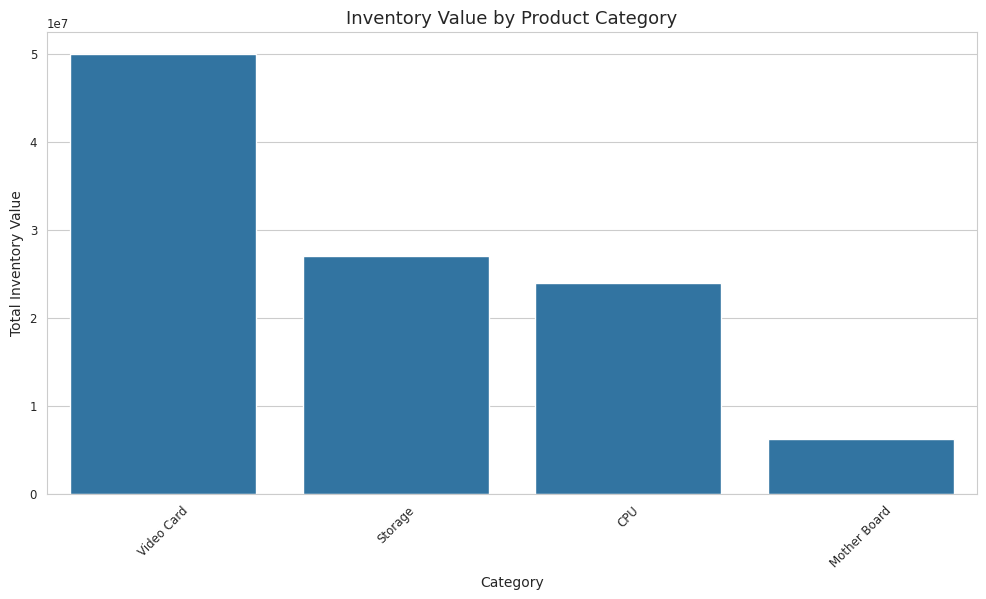

In [74]:

# ============================================================
# Research Question 1:
# Which product categories generate the highest inventory value?
# ============================================================

category_value = (
    df.groupby("CATEGORY_NAME", as_index=False)["INVENTORY_VALUE"]
    .sum()
    .sort_values("INVENTORY_VALUE", ascending=False)
)

display(category_value)

sns.barplot(data=category_value, x="CATEGORY_NAME", y="INVENTORY_VALUE")
plt.title("Inventory Value by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Inventory Value")
plt.xticks(rotation=45)
plt.show()

CATEGORY_NAME
Video Card      50002644.28
Storage         26983527.61
CPU             23961375.29
Mother Board     6246737.14
Name: INVENTORY_VALUE, dtype: float64


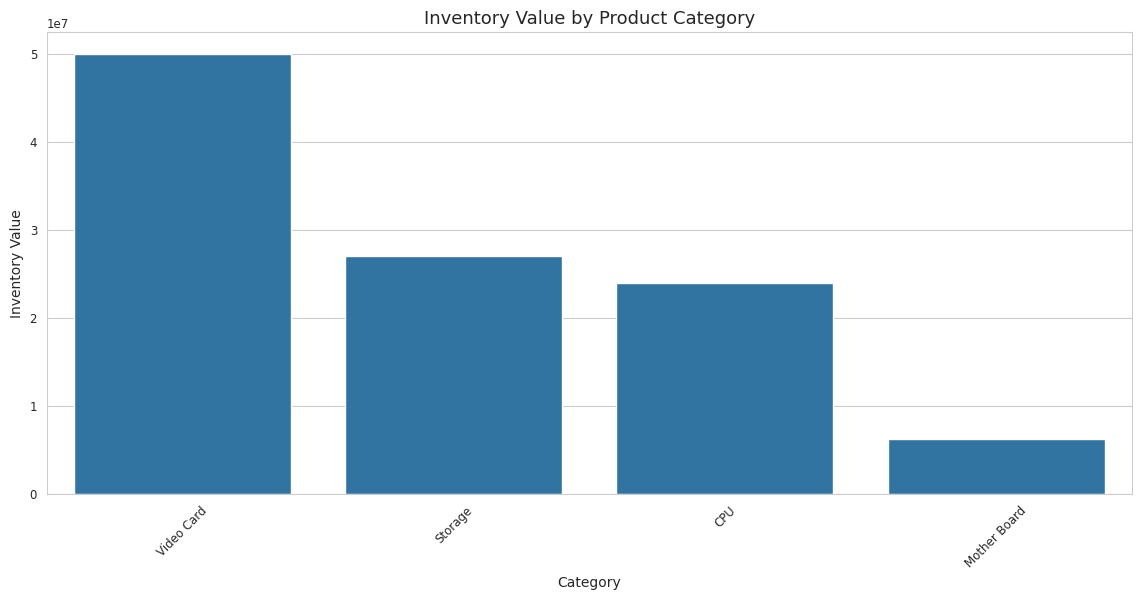

In [75]:
# ======================================================================
# RESEARCH QUESTION 1
# Which product categories hold the highest inventory value?
# ======================================================================

category_inventory = (
    df.groupby("CATEGORY_NAME")["INVENTORY_VALUE"]
    .sum()
    .sort_values(ascending=False)
)

print(category_inventory)

plt.figure(figsize=(14,6))

sns.barplot(
    x=category_inventory.index,
    y=category_inventory.values,
)

plt.title("Inventory Value by Product Category")
plt.xlabel("Category")
plt.ylabel("Inventory Value")

plt.xticks(rotation=45)

plt.show()

,PRODUCT_NAME,PROFIT_MARGIN_%
155,Supermicro X10SDV-8C-TLN4F,30.000316
40,EVGA 06G-P4-4998-KR,29.759497
170,Zotac ZT-P10810C-10P,29.600389
114,MSI X299 GAMING PRO CARBON AC,29.309375
4,AMD 100-506061,29.300293
168,Zotac ZT-70203-10P,29.269690
31,Asus Z10PE-D16 WS,29.249559
158,Western Digital WD101KRYZ,29.230908
73,Intel Xeon E5-1650 V3,29.230470
150,Seagate ST2000DX002,29.135070


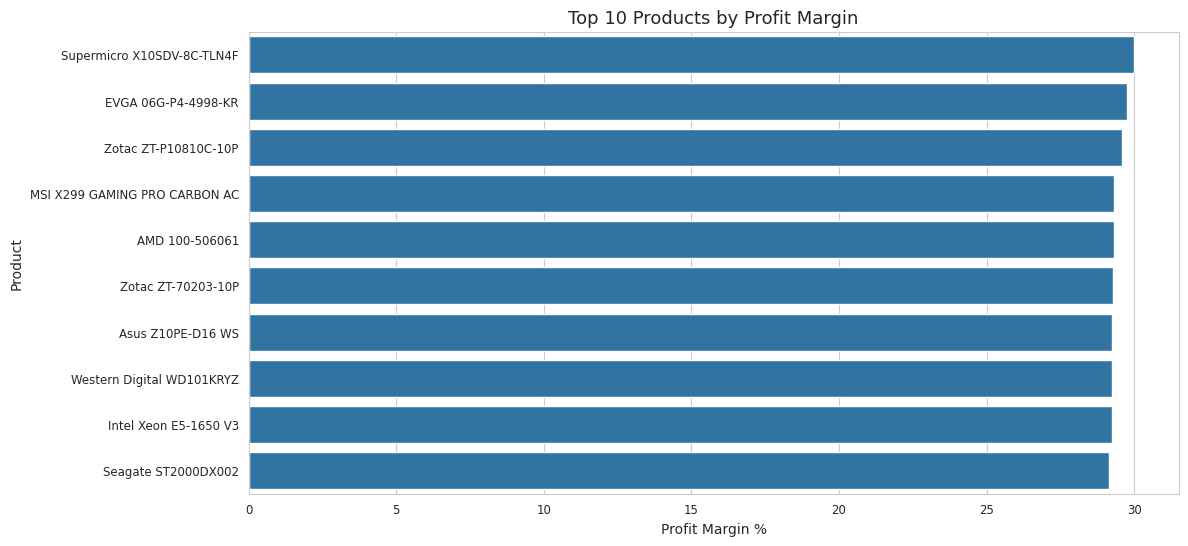

In [76]:
# ============================================================
# Research Question 2:
# Which products have the highest profit margin?
# ============================================================

product_margin = (
    df.groupby("PRODUCT_NAME", as_index=False)["PROFIT_MARGIN_%"]
    .mean()
    .sort_values("PROFIT_MARGIN_%", ascending=False)
    .head(10)
)

display(product_margin)

sns.barplot(data=product_margin, x="PROFIT_MARGIN_%", y="PRODUCT_NAME")
plt.title("Top 10 Products by Profit Margin")
plt.xlabel("Profit Margin %")
plt.ylabel("Product")
plt.show()

,WAREHOUSE_NAME,QUANTITY
4,San Francisco,28613
7,Sydney,20457
5,"Seattle, Washington",14860
0,Beijing,13482
8,Toronto,12969
2,Mexico City,9039
1,Bombay,7357
3,New Jersey,7252
6,"Southlake, Texas",5483


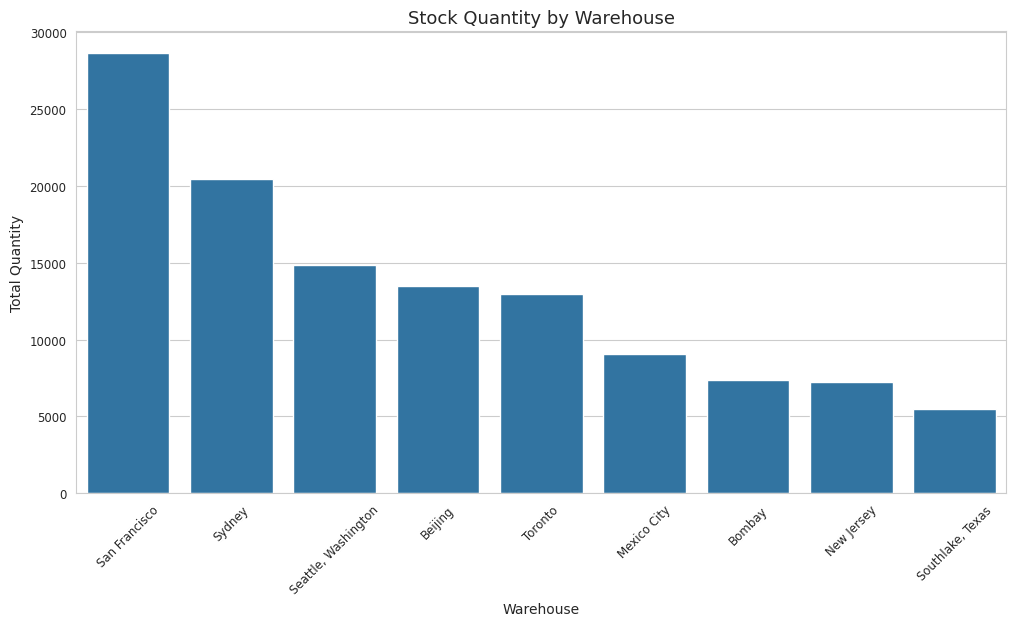

In [77]:
# ============================================================
# Research Question 3:
# Which warehouses hold the highest stock quantity?
# ============================================================

warehouse_stock = (
    df.groupby("WAREHOUSE_NAME", as_index=False)["QUANTITY"]
    .sum()
    .sort_values("QUANTITY", ascending=False)
)

display(warehouse_stock)

sns.barplot(data=warehouse_stock, x="WAREHOUSE_NAME", y="QUANTITY")
plt.title("Stock Quantity by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.show()

,COUNTRY_NAME,INVENTORY_VALUE
5,United States of America,55277346.09
0,Australia,16290208.92
1,Canada,11069529.26
2,China,10265446.19
3,India,7172004.27
4,Mexico,7119749.59


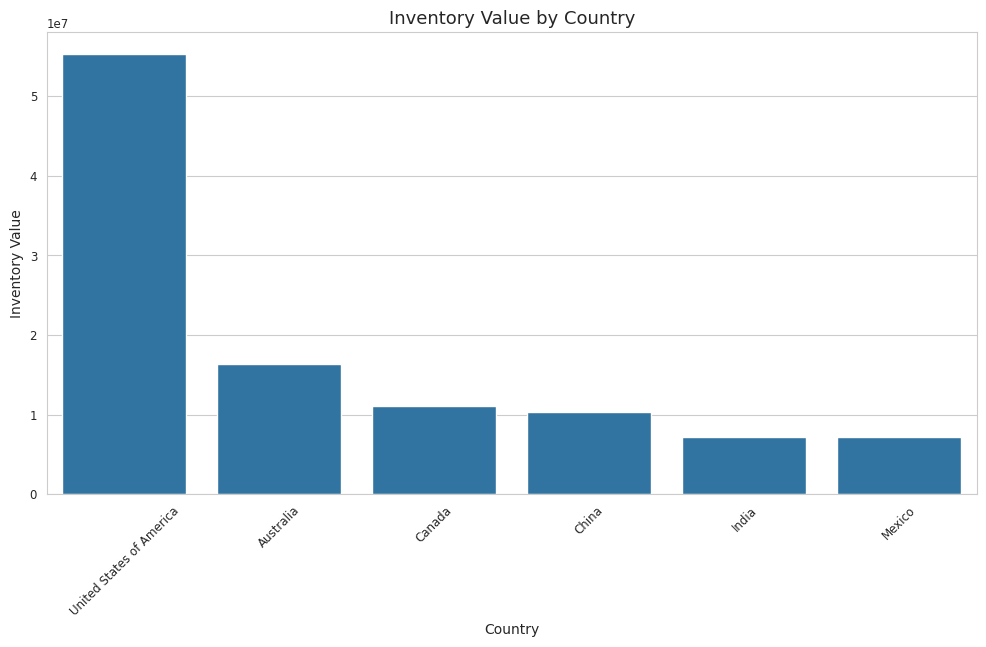

In [78]:
# ============================================================
# Research Question 4:
# Which country has the highest inventory value?
# ============================================================

country_value = (
    df.groupby("COUNTRY_NAME", as_index=False)["INVENTORY_VALUE"]
    .sum()
    .sort_values("INVENTORY_VALUE", ascending=False)
)

display(country_value)

sns.barplot(data=country_value, x="COUNTRY_NAME", y="INVENTORY_VALUE")
plt.title("Inventory Value by Country")
plt.xlabel("Country")
plt.ylabel("Inventory Value")
plt.xticks(rotation=45)
plt.show()

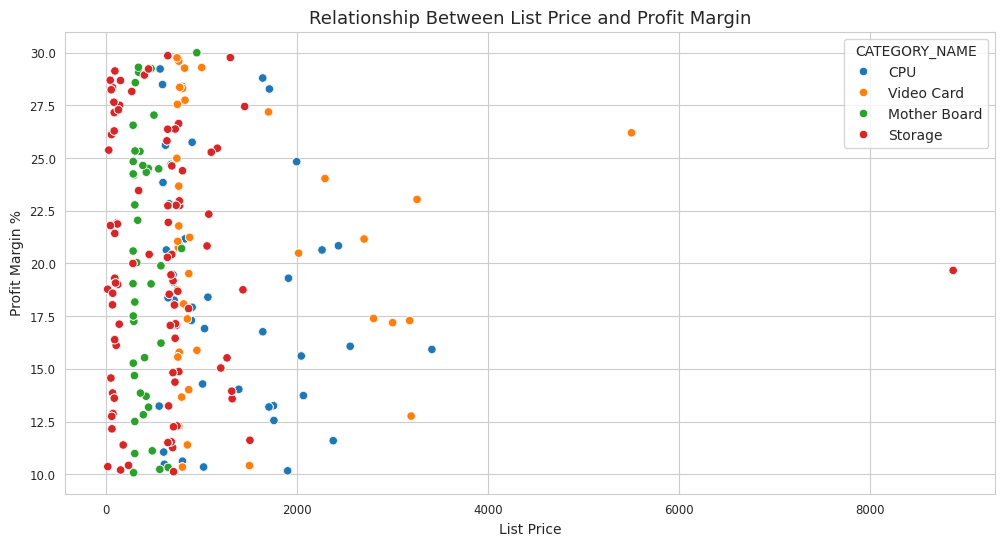

In [79]:
# ============================================================
# Research Question 5:
# Are expensive products also more profitable?
# ============================================================

sns.scatterplot(
    data=df,
    x="LIST_PRICE",
    y="PROFIT_MARGIN_%",
    hue="CATEGORY_NAME"
)
plt.title("Relationship Between List Price and Profit Margin")
plt.xlabel("List Price")
plt.ylabel("Profit Margin %")
plt.show()

In [80]:
# ============================================================
# 6. KPI Summary
# ============================================================

total_products = df["PRODUCT_NAME"].nunique()
total_quantity = df["QUANTITY"].sum()
total_inventory_value = df["INVENTORY_VALUE"].sum()
avg_profit_margin = df["PROFIT_MARGIN_%"].mean()
total_potential_profit = df["POTENTIAL_PROFIT"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Unique Products",
        "Total Stock Quantity",
        "Total Inventory Value",
        "Average Profit Margin %",
        "Total Potential Profit"
    ],
    "Value": [
        total_products,
        total_quantity,
        round(total_inventory_value, 2),
        round(avg_profit_margin, 2),
        round(total_potential_profit, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Unique Products,1.730000e+02
1,Total Stock Quantity,1.195120e+05
2,Total Inventory Value,1.071943e+08
3,Average Profit Margin %,1.974000e+01
4,Total Potential Profit,2.136745e+07


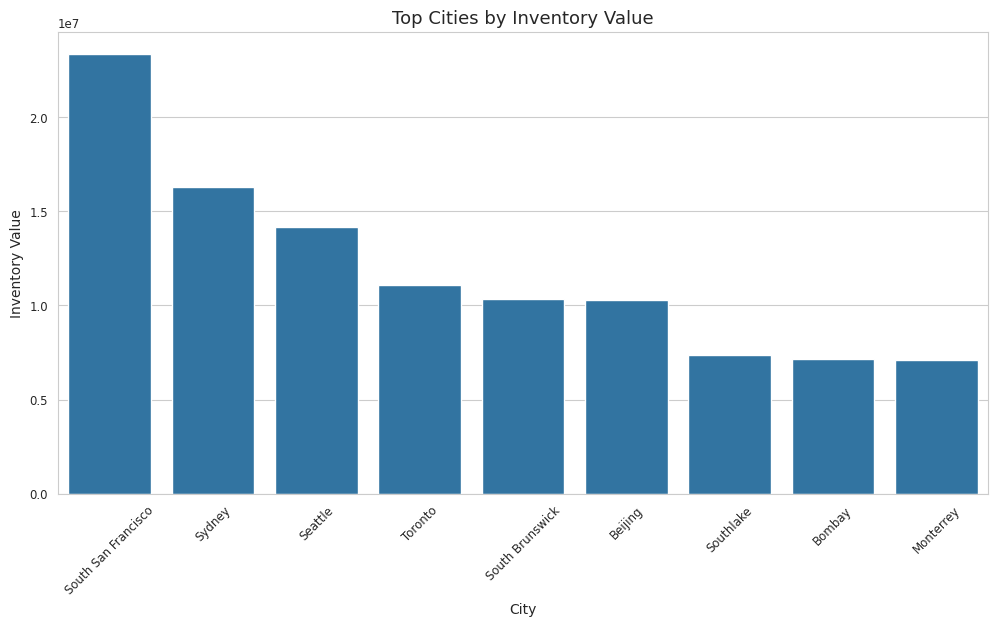

In [81]:
# ======================================================================
# RESEARCH QUESTION 6
# Which cities have the highest inventory value?
# ======================================================================

city_inventory = (
    df.groupby("CITY")["INVENTORY_VALUE"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=city_inventory.index,
    y=city_inventory.values
)

plt.title("Top Cities by Inventory Value")
plt.xlabel("City")
plt.ylabel("Inventory Value")

plt.xticks(rotation=45)

plt.show()

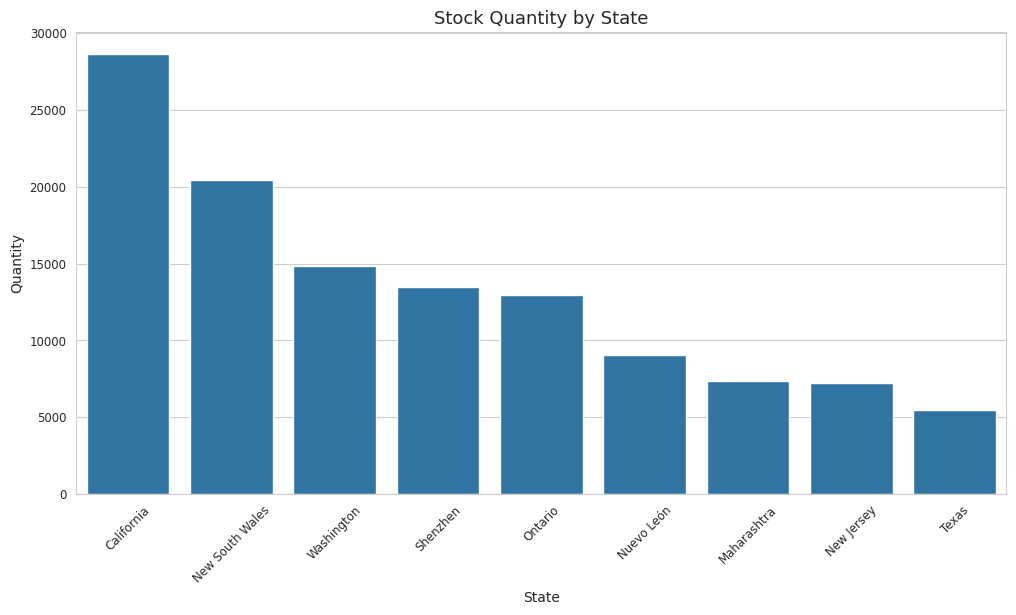

In [82]:
# ======================================================================
# RESEARCH QUESTION 7
# Which states have the highest stock quantity?
# ======================================================================

state_stock = (
    df.groupby("STATE")["QUANTITY"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_stock.index,
    y=state_stock.values
)

plt.title("Stock Quantity by State")
plt.xlabel("State")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

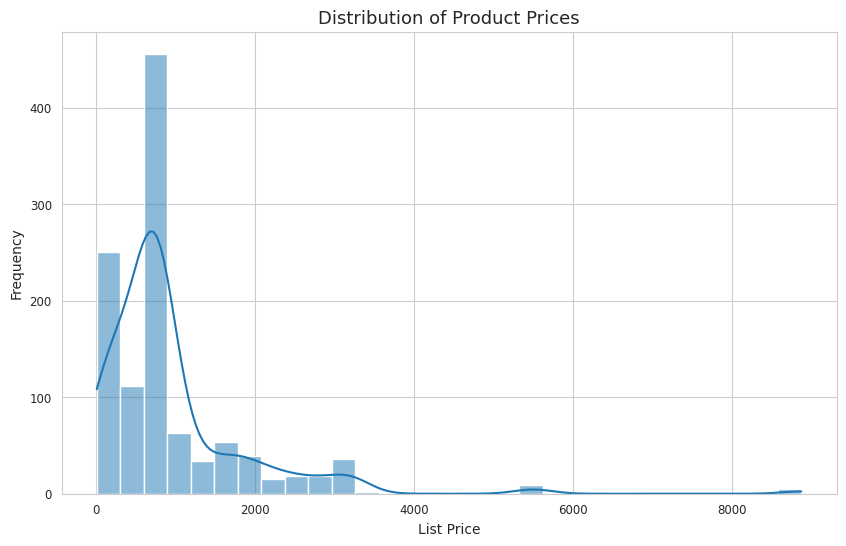

In [83]:
# ======================================================================
# RESEARCH QUESTION 8
# What is the distribution of product prices?
# ======================================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["LIST_PRICE"],
    bins=30,
    kde=True
)

plt.title("Distribution of Product Prices")
plt.xlabel("List Price")
plt.ylabel("Frequency")

plt.show()

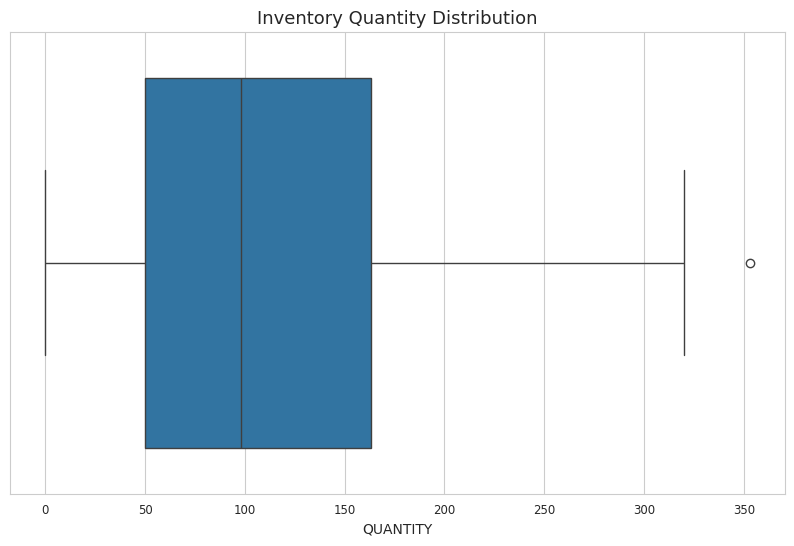

In [84]:
# ======================================================================
# RESEARCH QUESTION 9
# What is the distribution of inventory quantity?
# ======================================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["QUANTITY"]
)

plt.title("Inventory Quantity Distribution")

plt.show()

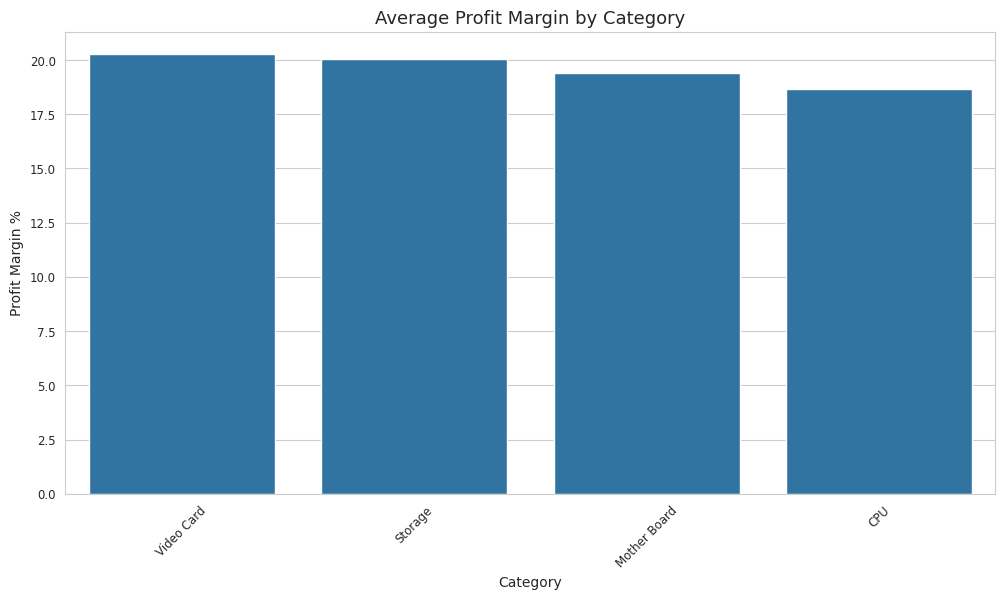

In [85]:
# ======================================================================
# RESEARCH QUESTION 10
# Which categories have the highest average profit margin?
# ======================================================================

category_margin = (
    df.groupby("CATEGORY_NAME")["PROFIT_MARGIN_%"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_margin.index,
    y=category_margin.values
)

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin %")

plt.xticks(rotation=45)

plt.show()

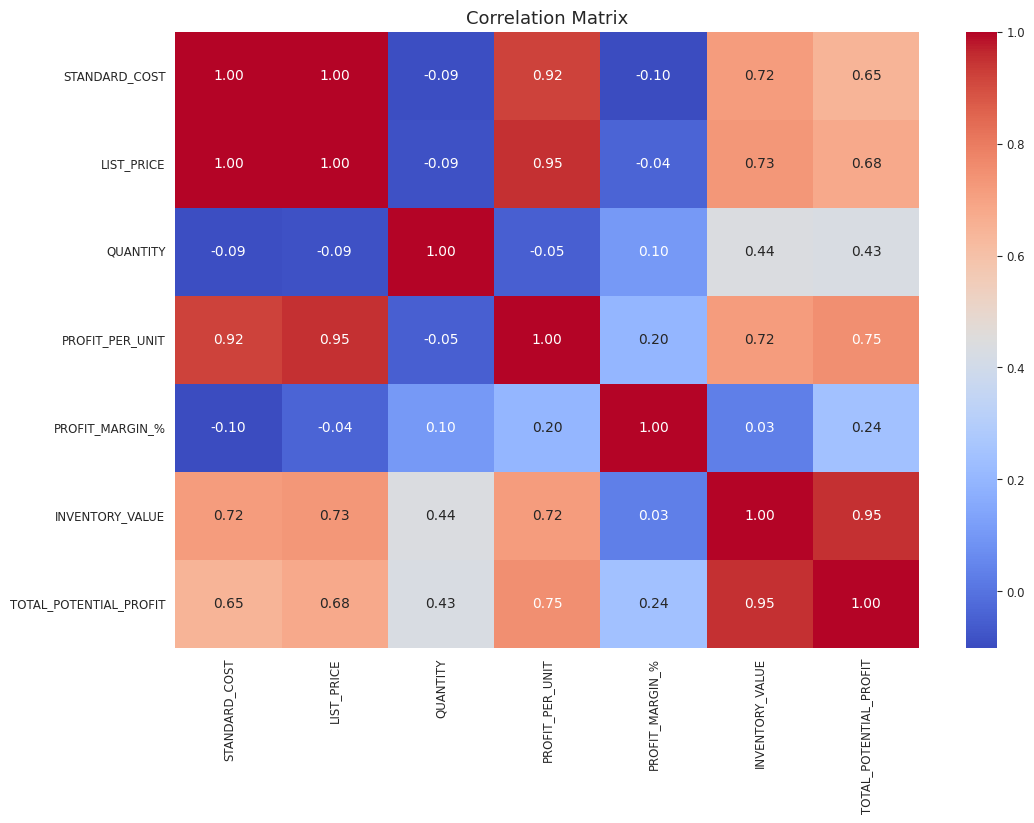

In [86]:
# ======================================================================
# RESEARCH QUESTION 11
# Correlation Analysis
# ======================================================================

correlation_columns = [
    "STANDARD_COST",
    "LIST_PRICE",
    "QUANTITY",
    "PROFIT_PER_UNIT",
    "PROFIT_MARGIN_%",
    "INVENTORY_VALUE",
    "TOTAL_POTENTIAL_PROFIT"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

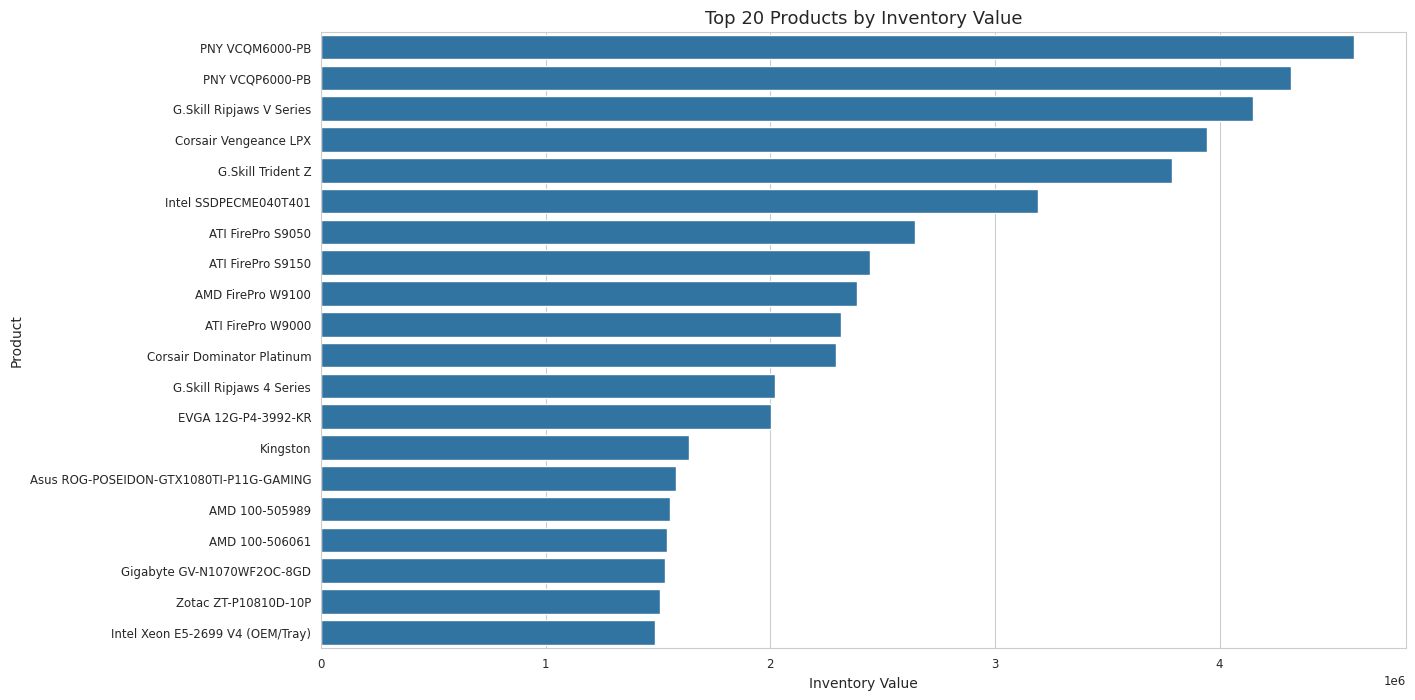

In [87]:
# ======================================================================
# RESEARCH QUESTION 12
# Top 20 High Value Inventory Products
# ======================================================================

high_value_products = (
    df.groupby("PRODUCT_NAME")["INVENTORY_VALUE"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=high_value_products.values,
    y=high_value_products.index
)

plt.title("Top 20 Products by Inventory Value")
plt.xlabel("Inventory Value")
plt.ylabel("Product")

plt.show()

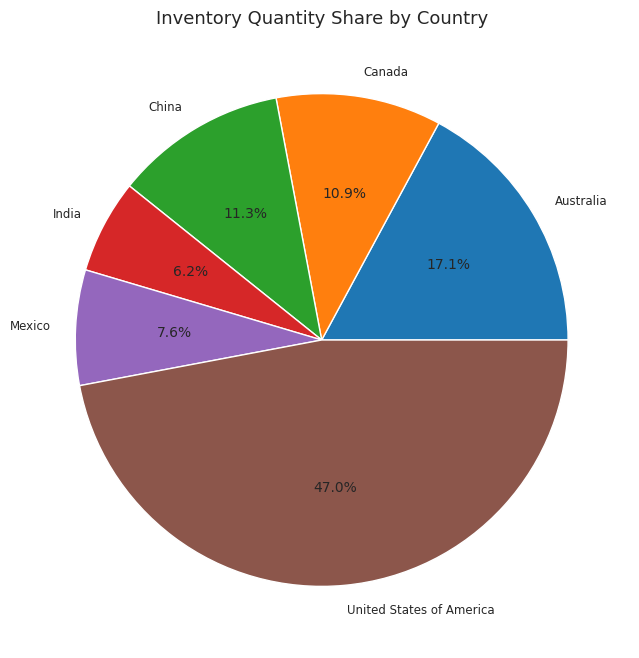

In [88]:
# ======================================================================
# RESEARCH QUESTION 13
# Inventory Concentration by Country
# ======================================================================

country_qty = (
    df.groupby("COUNTRY_NAME")["QUANTITY"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    country_qty.values,
    labels=country_qty.index,
    autopct='%1.1f%%'
)

plt.title("Inventory Quantity Share by Country")

plt.show()

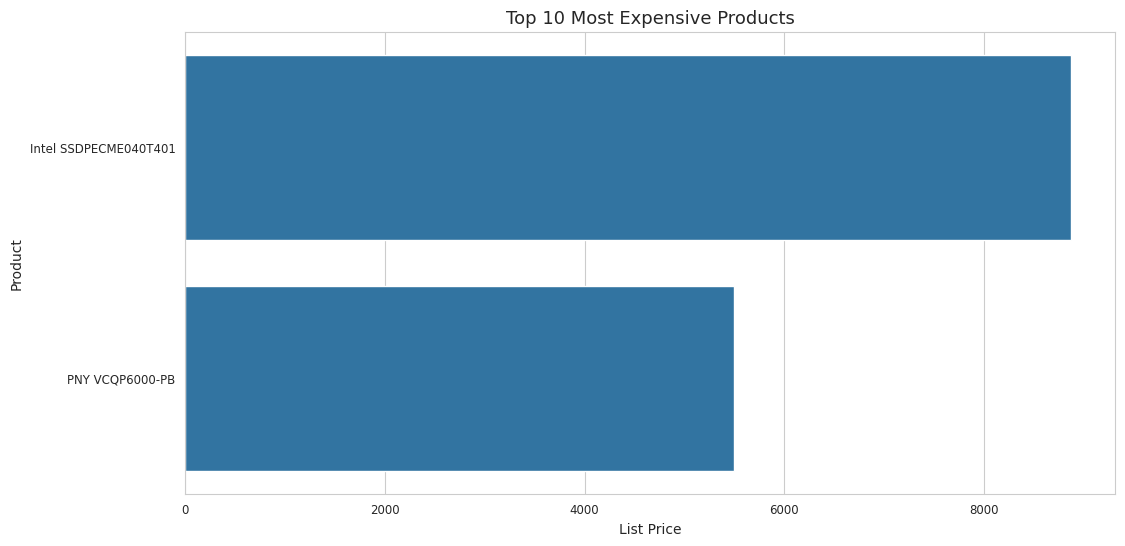

In [89]:
# ======================================================================
# RESEARCH QUESTION 14
# Most Expensive Products
# ======================================================================

expensive_products = (
    df[["PRODUCT_NAME","LIST_PRICE"]]
    .sort_values("LIST_PRICE", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=expensive_products,
    x="LIST_PRICE",
    y="PRODUCT_NAME"
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("List Price")
plt.ylabel("Product")

plt.show()


### DATA SCIENCE


In [90]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

In [91]:
OUT = "/mnt/user-data/outputs"
os.makedirs(OUT, exist_ok=True)

PALETTE = ['#1B3A6B','#2E86AB','#F18F01','#C73E1D','#3A86FF','#06D6A0']
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

In [92]:
df.columns

Index(['CATEGORY_ID', 'CATEGORY_NAME', 'PRODUCT_ID', 'PRODUCT_NAME',
       'DESCRIPTION', 'DESCRIPTION_-_DETAIL_1', 'DESCRIPTION_-_DETAIL_2',
       'DESCRIPTION_-_DETAIL_3', 'DESCRIPTION_-_DETAIL_4', 'STANDARD_COST',
       'LIST_PRICE', 'COUNTRY_ID', 'REGION_ID', 'LOCATION_ID', 'WAREHOUSE_ID',
       'QUANTITY', 'WAREHOUSE_NAME', 'ADDRESS', 'POSTAL_CODE', 'CITY', 'STATE',
       'COUNTRY_NAME', 'PROFIT_PER_UNIT', 'PROFIT_MARGIN_%', 'INVENTORY_VALUE',
       'POTENTIAL_PROFIT', 'TOTAL_POTENTIAL_PROFIT'],
      dtype='object')

In [93]:
df['DESCRIPTION_-_DETAIL_3'] = df['DESCRIPTION_-_DETAIL_3'].fillna('N/A')
df['DESCRIPTION_-_DETAIL_4'] = df['DESCRIPTION_-_DETAIL_4'].fillna('N/A')

In [94]:
# ── FEATURE ENGINEERING ─────────────────────────────────────
df['PROFIT_PER_UNIT']   = df['LIST_PRICE'] - df['STANDARD_COST']
df['PROFIT_MARGIN_PCT'] = (df['PROFIT_PER_UNIT'] / df['LIST_PRICE']) * 100
df['INVENTORY_VALUE']   = df['STANDARD_COST'] * df['QUANTITY']
df['POTENTIAL_REVENUE'] = df['LIST_PRICE']    * df['QUANTITY']
df['POTENTIAL_PROFIT']  = df['PROFIT_PER_UNIT'] * df['QUANTITY']
df['MARKUP_PCT']        = ((df['LIST_PRICE'] - df['STANDARD_COST']) / df['STANDARD_COST']) * 100


In [95]:
# Stock risk – pure Python vectorized
def classify_stock(q):
    if q == 0:     return 'Dead Stock'
    elif q <= 20:  return 'Critical Low'
    elif q <= 60:  return 'Low'
    elif q <= 150: return 'Healthy'
    else:          return 'Overstock'

df['STOCK_RISK'] = df['QUANTITY'].apply(classify_stock)

# ABC by inventory value
df_s = df.sort_values('INVENTORY_VALUE', ascending=False).copy()
cum = df_s['INVENTORY_VALUE'].cumsum() / df_s['INVENTORY_VALUE'].sum() * 100
df_s['ABC_CLASS'] = 'C'
df_s.loc[cum <= 80, 'ABC_CLASS'] = 'A'
df_s.loc[(cum > 80) & (cum <= 95), 'ABC_CLASS'] = 'B'
df = df.merge(df_s[['PRODUCT_ID','WAREHOUSE_ID','ABC_CLASS']],
              on=['PRODUCT_ID','WAREHOUSE_ID'], how='left')

In [96]:
# ── AGGREGATIONS ─────────────────────────────────────────────
cat_agg  = df.groupby('CATEGORY_NAME').agg(
    Units=('QUANTITY','sum'),
    InvValue=('INVENTORY_VALUE','sum'),
    PotRevenue=('POTENTIAL_REVENUE','sum'),
    PotProfit=('POTENTIAL_PROFIT','sum'),
    AvgMargin=('PROFIT_MARGIN_PCT','mean'),
    NumProducts=('PRODUCT_ID','nunique'),
).reset_index()

wh_agg = df.groupby('WAREHOUSE_NAME').agg(
    Units=('QUANTITY','sum'),
    InvValue=('INVENTORY_VALUE','sum'),
    PotProfit=('POTENTIAL_PROFIT','sum'),
    NumProducts=('PRODUCT_ID','nunique'),
).reset_index()

cty_agg = df.groupby('COUNTRY_NAME').agg(
    Units=('QUANTITY','sum'),
    InvValue=('INVENTORY_VALUE','sum'),
    PotProfit=('POTENTIAL_PROFIT','sum'),
).reset_index()

prod_agg = df.groupby(['PRODUCT_ID','PRODUCT_NAME','CATEGORY_NAME']).agg(
    Units=('QUANTITY','sum'),
    InvValue=('INVENTORY_VALUE','sum'),
    PotRevenue=('POTENTIAL_REVENUE','sum'),
    PotProfit=('POTENTIAL_PROFIT','sum'),
    AvgMargin=('PROFIT_MARGIN_PCT','mean'),
    AvgPrice=('LIST_PRICE','mean'),
    AvgCost=('STANDARD_COST','mean'),
).reset_index()

# ── KPIs ────────────────────────────────────────────────────
total_inv_val  = df['INVENTORY_VALUE'].sum()
total_pot_rev  = df['POTENTIAL_REVENUE'].sum()
total_pot_prof = df['POTENTIAL_PROFIT'].sum()
avg_margin     = df['PROFIT_MARGIN_PCT'].mean()
total_units    = df['QUANTITY'].sum()

print("KPIs loaded.")


KPIs loaded.


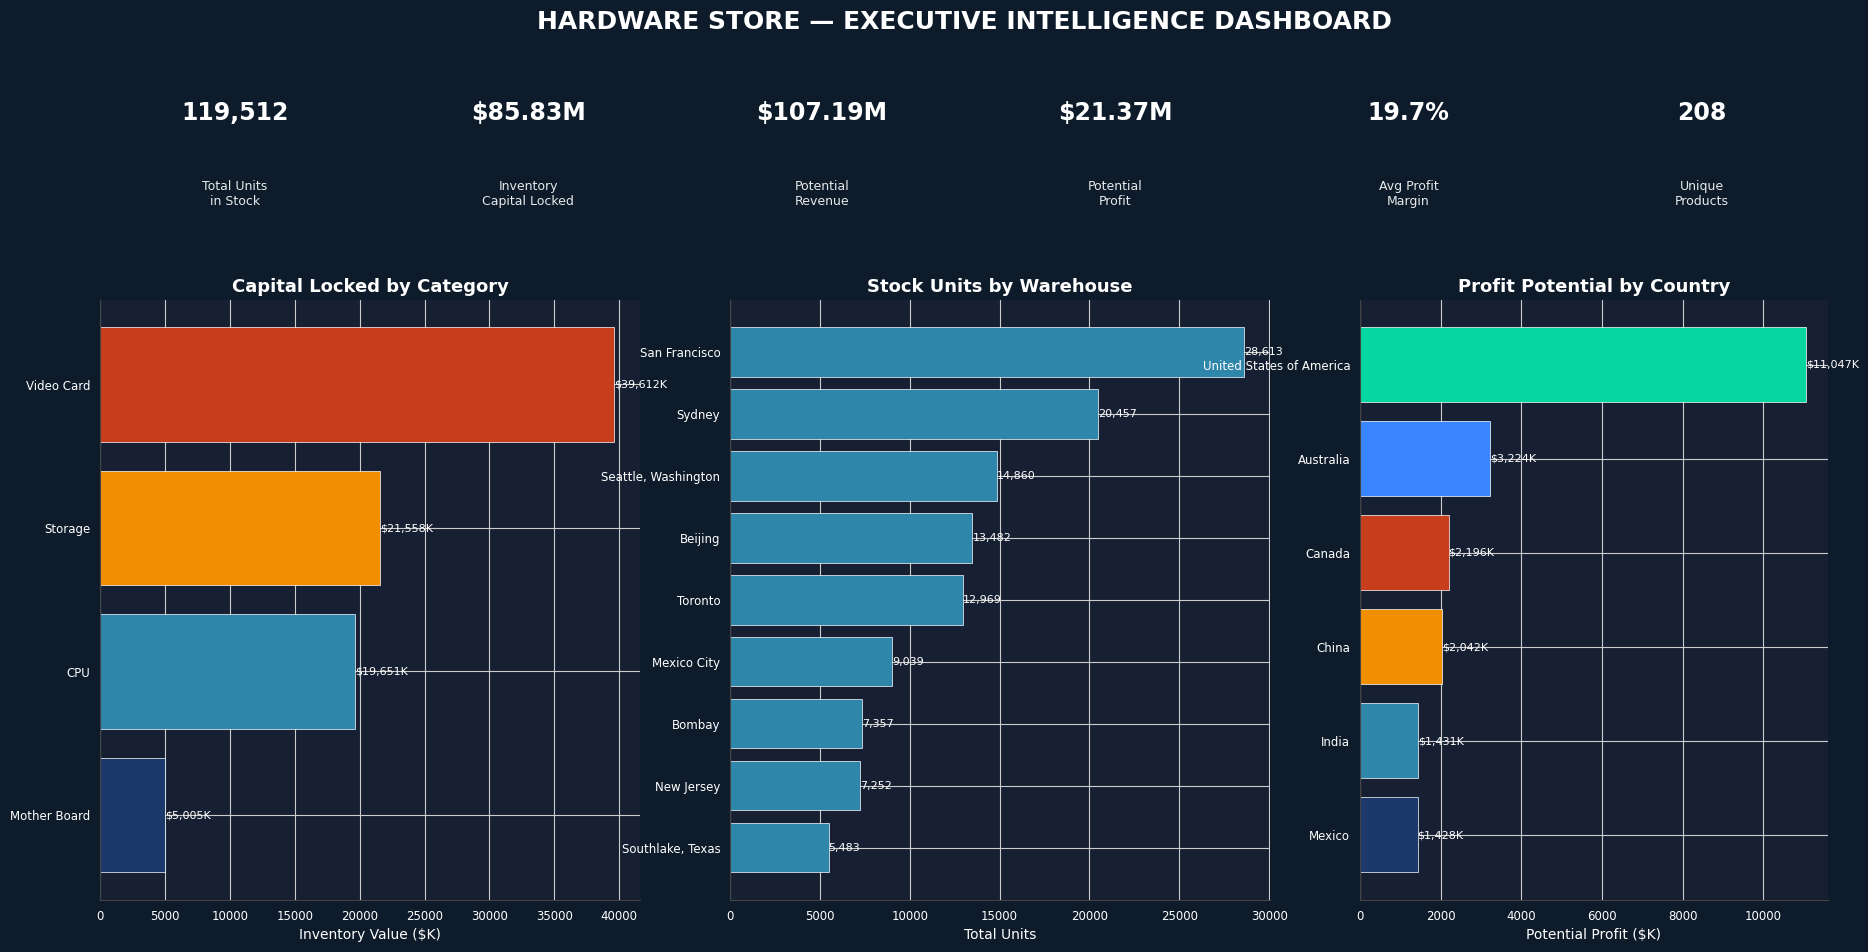

<Figure size 1200x600 with 0 Axes>

Chart 1 saved.


In [97]:

# ============================================================
# CHART 1 – EXECUTIVE KPI DASHBOARD
# ============================================================
%matplotlib inline
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0D1B2A')
fig.suptitle('HARDWARE STORE — EXECUTIVE INTELLIGENCE DASHBOARD',
             fontsize=18, fontweight='bold', color='white', y=0.97)

# KPI cards (top row)
kpis = [
    ('Total Units\nin Stock',     f'{total_units:,}',        '#2E86AB'),
    ('Inventory\nCapital Locked', f'${total_inv_val/1e6:.2f}M', '#F18F01'),
    ('Potential\nRevenue',        f'${total_pot_rev/1e6:.2f}M', '#3A86FF'),
    ('Potential\nProfit',         f'${total_pot_prof/1e6:.2f}M', '#06D6A0'),
    ('Avg Profit\nMargin',        f'{avg_margin:.1f}%',       '#C73E1D'),
    ('Unique\nProducts',          f'{df["PRODUCT_ID"].nunique()}', '#9B5DE5'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_axes([0.02 + i*0.163, 0.75, 0.15, 0.18])
    ax.set_facecolor(color)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.text(0.5, 0.65, val, ha='center', va='center',
            fontsize=17, fontweight='bold', color='white')
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9)
    for spine in ['top','right','bottom','left']:
        ax.spines[spine].set_visible(False)

# Chart A – Category Inventory Value
ax1 = fig.add_axes([0.02, 0.08, 0.30, 0.60])
cat_sorted = cat_agg.sort_values('InvValue', ascending=True)
bars = ax1.barh(cat_sorted['CATEGORY_NAME'], cat_sorted['InvValue']/1e3,
                color=PALETTE[:len(cat_sorted)], edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Inventory Value ($K)', color='white')
ax1.set_title('Capital Locked by Category', color='white', fontweight='bold')
ax1.set_facecolor('#162032')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for bar in bars:
    w = bar.get_width()
    ax1.text(w+10, bar.get_y()+bar.get_height()/2,
             f'${w:,.0f}K', va='center', fontsize=8, color='white')

# Chart B – Warehouse stock distribution
ax2 = fig.add_axes([0.37, 0.08, 0.30, 0.60])
wh_sorted = wh_agg.sort_values('Units', ascending=True)
bars2 = ax2.barh(wh_sorted['WAREHOUSE_NAME'], wh_sorted['Units'],
                 color='#2E86AB', edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Total Units', color='white')
ax2.set_title('Stock Units by Warehouse', color='white', fontweight='bold')
ax2.set_facecolor('#162032')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#444')
ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w+3, bar.get_y()+bar.get_height()/2,
             f'{w:,}', va='center', fontsize=8, color='white')

# Chart C – Country Potential Profit
ax3 = fig.add_axes([0.72, 0.08, 0.26, 0.60])
cty_sorted = cty_agg.sort_values('PotProfit', ascending=True)
bars3 = ax3.barh(cty_sorted['COUNTRY_NAME'], cty_sorted['PotProfit']/1e3,
                 color=PALETTE[:len(cty_sorted)], edgecolor='white', linewidth=0.5)
ax3.set_xlabel('Potential Profit ($K)', color='white')
ax3.set_title('Profit Potential by Country', color='white', fontweight='bold')
ax3.set_facecolor('#162032')
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
for bar in bars3:
    w = bar.get_width()
    ax3.text(w+1, bar.get_y()+bar.get_height()/2,
             f'${w:,.0f}K', va='center', fontsize=8, color='white')

plt.show()

plt.savefig(f'{OUT}/01_executive_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1B2A')
plt.show()
print("Chart 1 saved.")


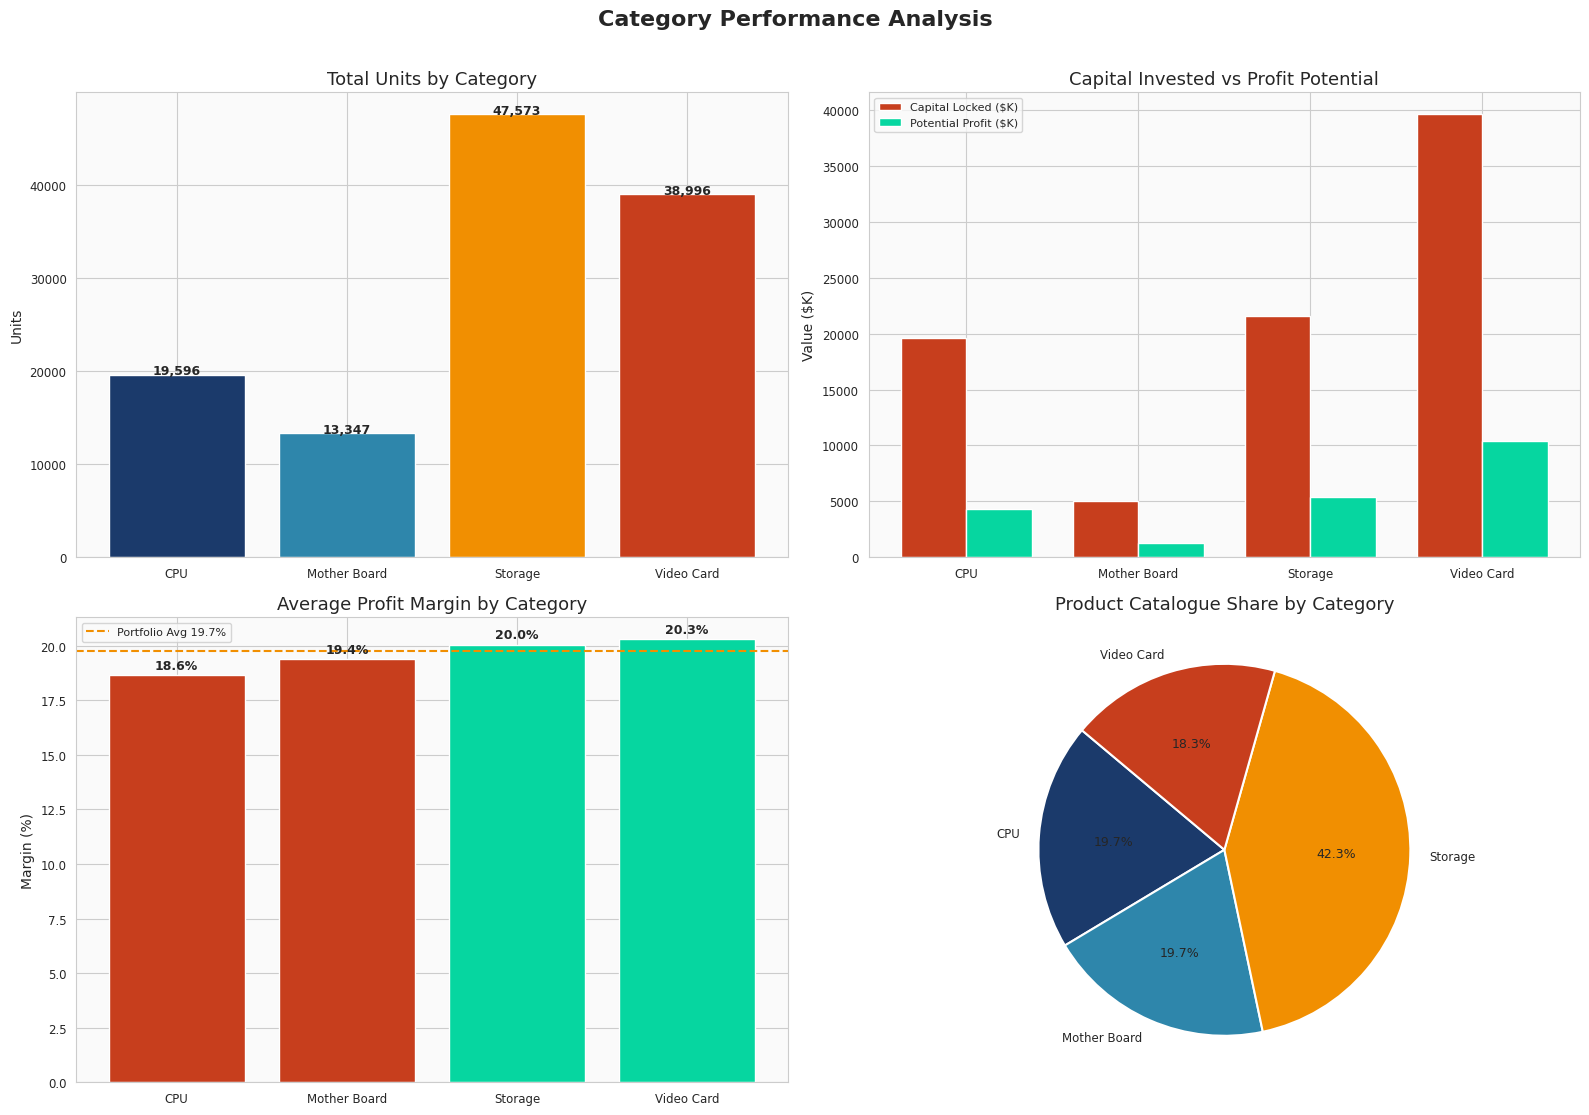

Chart 2 saved.


In [98]:

# ============================================================
# CHART 2 – CATEGORY DEEP DIVE (4-panel)
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Category Performance Analysis', fontsize=16, fontweight='bold', y=1.01)

# 2A – Units by category
ax = axes[0,0]
ax.bar(cat_agg['CATEGORY_NAME'], cat_agg['Units'],
       color=PALETTE[:4], edgecolor='white')
ax.set_title('Total Units by Category')
ax.set_ylabel('Units')
for i, (v, c) in enumerate(zip(cat_agg['Units'], cat_agg['CATEGORY_NAME'])):
    ax.text(i, v+50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 2B – Potential profit vs inventory value
ax = axes[0,1]
x = np.arange(len(cat_agg))
w = 0.38
b1 = ax.bar(x - w/2, cat_agg['InvValue']/1e3, w, label='Capital Locked ($K)', color='#C73E1D', edgecolor='white')
b2 = ax.bar(x + w/2, cat_agg['PotProfit']/1e3, w, label='Potential Profit ($K)', color='#06D6A0', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cat_agg['CATEGORY_NAME'])
ax.set_title('Capital Invested vs Profit Potential')
ax.set_ylabel('Value ($K)')
ax.legend(fontsize=8)

# 2C – Average profit margin by category
ax = axes[1,0]
colors_margin = ['#06D6A0' if m >= avg_margin else '#C73E1D' for m in cat_agg['AvgMargin']]
bars = ax.bar(cat_agg['CATEGORY_NAME'], cat_agg['AvgMargin'],
              color=colors_margin, edgecolor='white')
ax.axhline(avg_margin, color='#F18F01', linestyle='--', linewidth=1.5, label=f'Portfolio Avg {avg_margin:.1f}%')
ax.set_title('Average Profit Margin by Category')
ax.set_ylabel('Margin (%)')
ax.legend(fontsize=8)
for i, v in enumerate(cat_agg['AvgMargin']):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2D – Number of products per category
ax = axes[1,1]
wedges, texts, autotexts = ax.pie(
    cat_agg['NumProducts'],
    labels=cat_agg['CATEGORY_NAME'],
    autopct='%1.1f%%',
    colors=PALETTE[:4],
    startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for t in autotexts: t.set_fontsize(9)
ax.set_title('Product Catalogue Share by Category')

plt.tight_layout()
plt.savefig(f'{OUT}/02_category_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

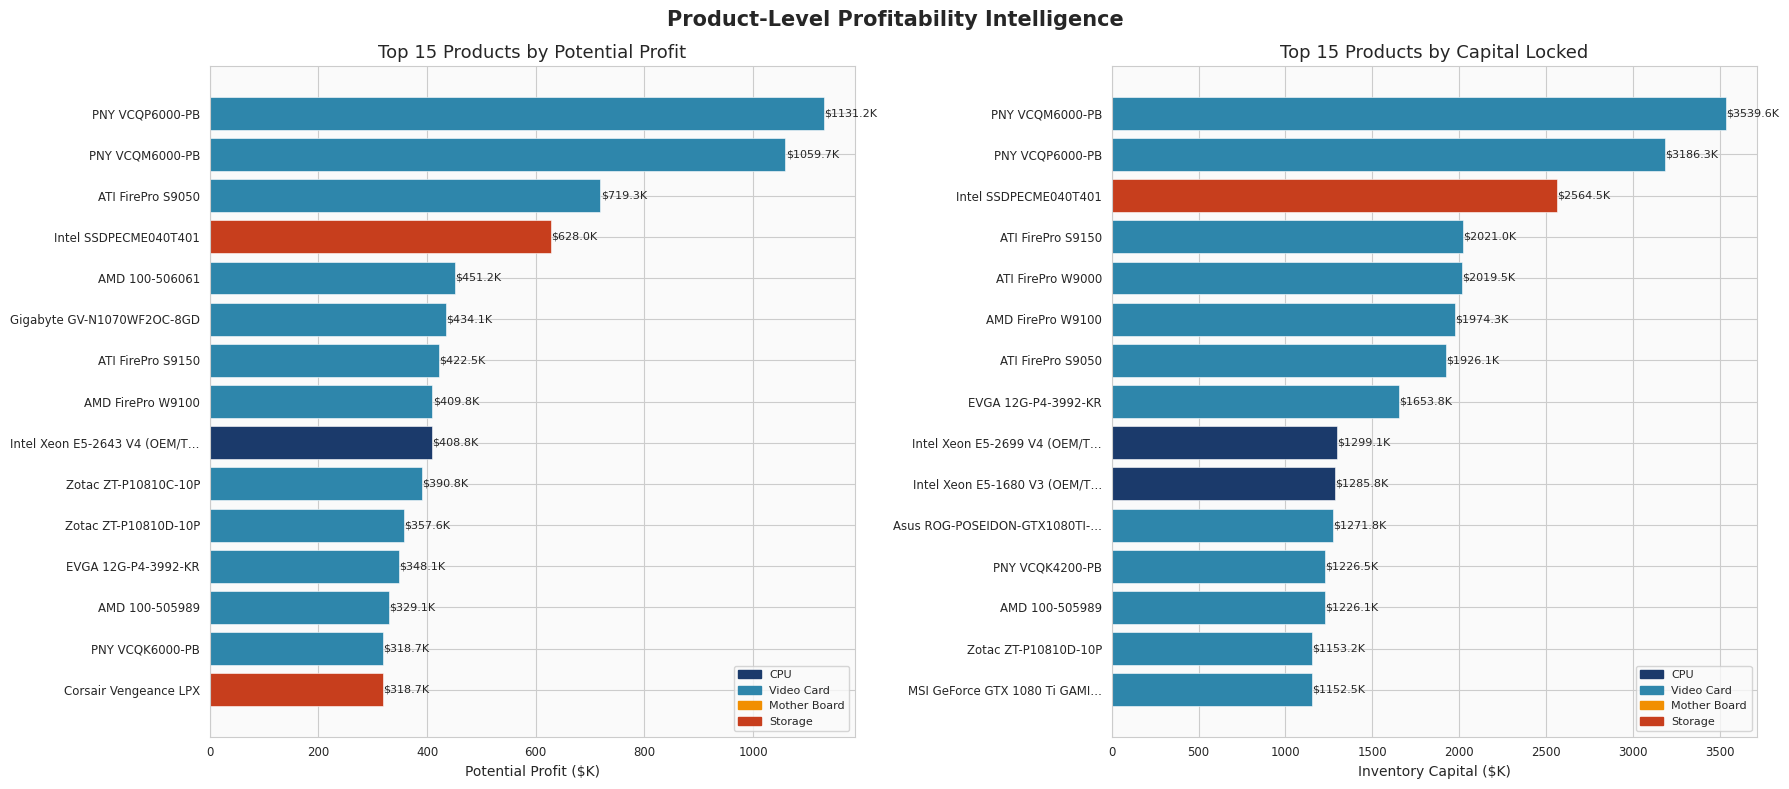

Chart 3 saved.


In [99]:

# ============================================================
# CHART 3 – TOP 15 PRODUCTS (Profit & Value)
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Product-Level Profitability Intelligence', fontsize=15, fontweight='bold')

top15_prof = prod_agg.nlargest(15, 'PotProfit')
top15_val  = prod_agg.nlargest(15, 'InvValue')

# Short name helper
def shorten(name, n=28):
    return name[:n]+'…' if len(name) > n else name

ax = axes[0]
colors = [PALETTE[['CPU','Video Card','Mother Board','Storage'].index(c)] for c in top15_prof['CATEGORY_NAME']]
bars = ax.barh([shorten(n) for n in top15_prof['PRODUCT_NAME']],
               top15_prof['PotProfit']/1e3,
               color=colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Potential Profit ($K)')
ax.set_title('Top 15 Products by Potential Profit')
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2,
            f'${w:.1f}K', va='center', fontsize=8)
# legend
patches = [mpatches.Patch(color=PALETTE[i], label=c)
           for i,c in enumerate(['CPU','Video Card','Mother Board','Storage'])]
ax.legend(handles=patches, fontsize=8, loc='lower right')

ax = axes[1]
colors2 = [PALETTE[['CPU','Video Card','Mother Board','Storage'].index(c)] for c in top15_val['CATEGORY_NAME']]
bars2 = ax.barh([shorten(n) for n in top15_val['PRODUCT_NAME']],
                top15_val['InvValue']/1e3,
                color=colors2, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Inventory Capital ($K)')
ax.set_title('Top 15 Products by Capital Locked')
ax.invert_yaxis()
for bar in bars2:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2,
            f'${w:.1f}K', va='center', fontsize=8)
ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUT}/03_product_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")


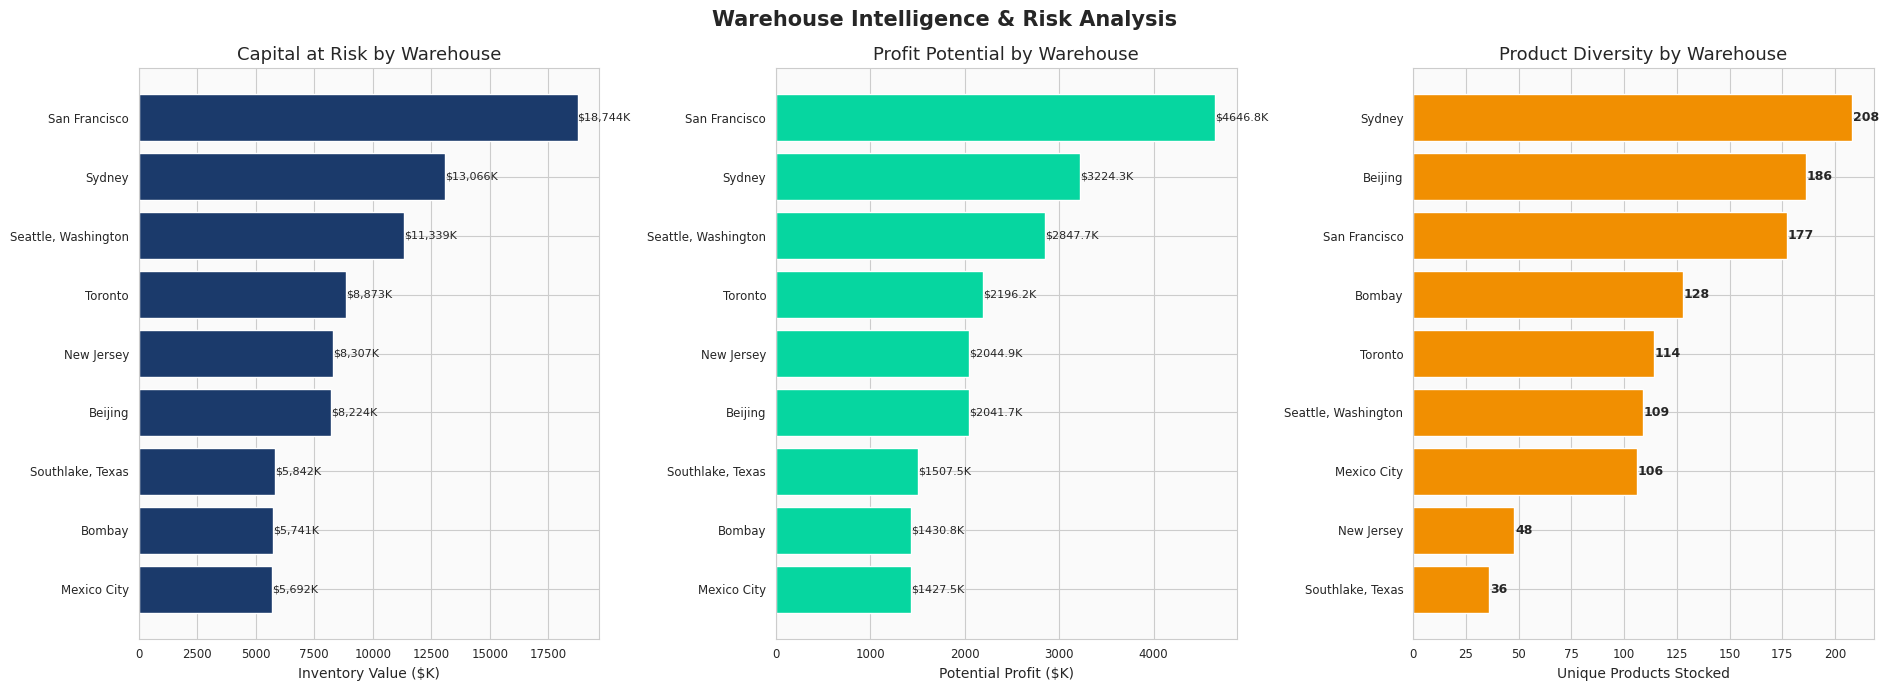

Chart 4 saved.


In [100]:

# ============================================================
# CHART 4 – WAREHOUSE INTELLIGENCE
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle('Warehouse Intelligence & Risk Analysis', fontsize=15, fontweight='bold')

# 4A – Inventory value by warehouse
ax = axes[0]
wh_val = wh_agg.sort_values('InvValue', ascending=True)
ax.barh(wh_val['WAREHOUSE_NAME'], wh_val['InvValue']/1e3,
        color='#1B3A6B', edgecolor='white')
ax.set_xlabel('Inventory Value ($K)')
ax.set_title('Capital at Risk by Warehouse')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+1, bar.get_y()+bar.get_height()/2,
            f'${w:,.0f}K', va='center', fontsize=8)

# 4B – Potential profit by warehouse
ax = axes[1]
wh_pf = wh_agg.sort_values('PotProfit', ascending=True)
ax.barh(wh_pf['WAREHOUSE_NAME'], wh_pf['PotProfit']/1e3,
        color='#06D6A0', edgecolor='white')
ax.set_xlabel('Potential Profit ($K)')
ax.set_title('Profit Potential by Warehouse')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+1, bar.get_y()+bar.get_height()/2,
            f'${w:.1f}K', va='center', fontsize=8)

# 4C – Product diversity by warehouse
ax = axes[2]
wh_agg_s = wh_agg.sort_values('NumProducts', ascending=True)
ax.barh(wh_agg_s['WAREHOUSE_NAME'], wh_agg_s['NumProducts'],
        color='#F18F01', edgecolor='white')
ax.set_xlabel('Unique Products Stocked')
ax.set_title('Product Diversity by Warehouse')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+0.3, bar.get_y()+bar.get_height()/2,
            f'{w:.0f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT}/04_warehouse_intelligence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

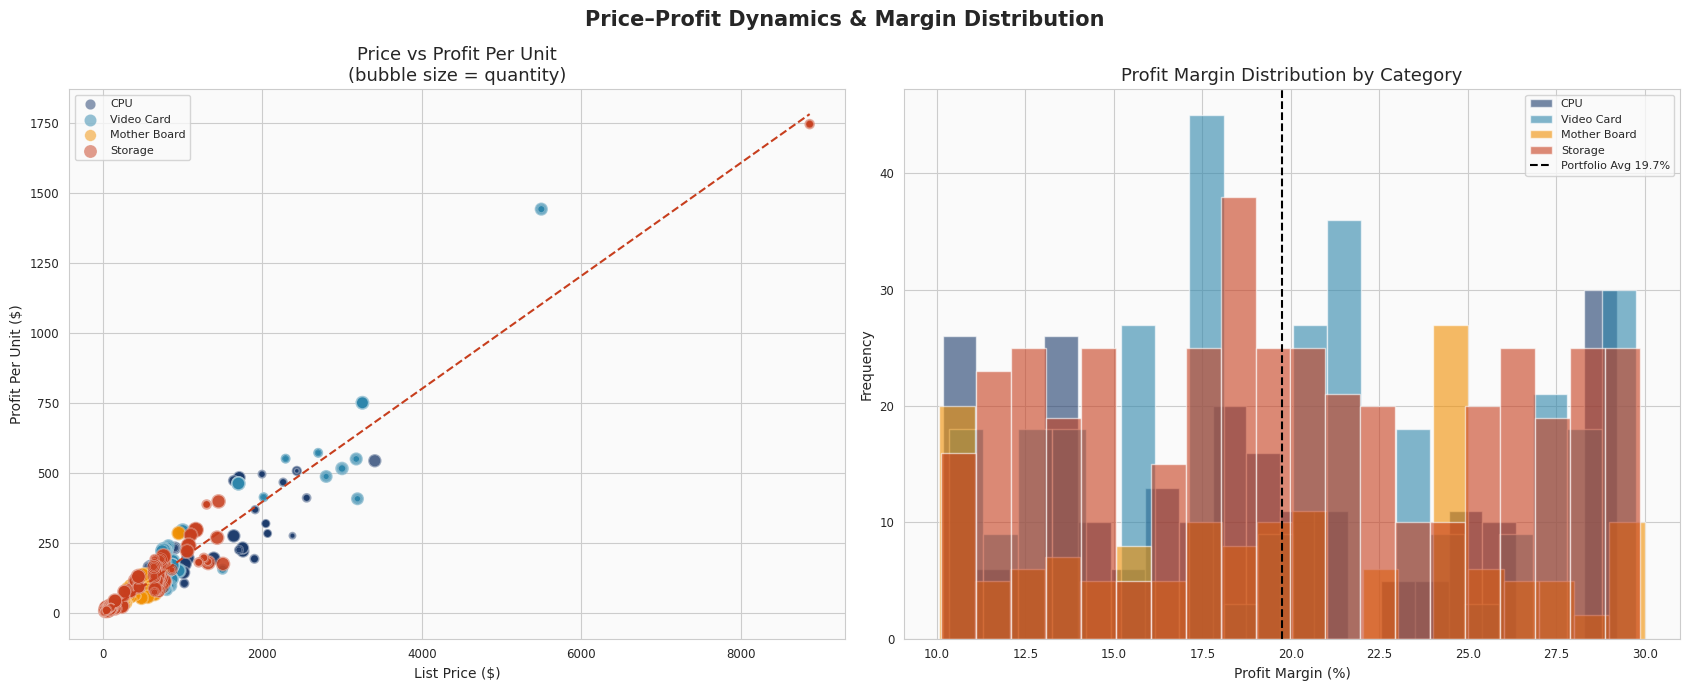

Chart 5 saved.


In [101]:

# ============================================================
# CHART 5 – PRICE vs PROFIT SCATTER + MARGIN DISTRIBUTION
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Price–Profit Dynamics & Margin Distribution', fontsize=15, fontweight='bold')

cat_list = ['CPU','Video Card','Mother Board','Storage']
cat_color_map = {c: PALETTE[i] for i,c in enumerate(cat_list)}

ax = axes[0]
for cat in cat_list:
    sub = df[df['CATEGORY_NAME'] == cat]
    ax.scatter(sub['LIST_PRICE'], sub['PROFIT_PER_UNIT'],
               alpha=0.5, s=sub['QUANTITY']/2,
               color=cat_color_map[cat], label=cat, edgecolors='white', linewidths=0.3)
ax.set_xlabel('List Price ($)')
ax.set_ylabel('Profit Per Unit ($)')
ax.set_title('Price vs Profit Per Unit\n(bubble size = quantity)')
ax.legend(fontsize=8)
# trend line
m, b = np.polyfit(df['LIST_PRICE'], df['PROFIT_PER_UNIT'], 1)
xline = np.linspace(df['LIST_PRICE'].min(), df['LIST_PRICE'].max(), 100)
ax.plot(xline, m*xline+b, '--', color='#C73E1D', linewidth=1.5, label='Trend')

ax = axes[1]
for cat in cat_list:
    sub = df[df['CATEGORY_NAME'] == cat]['PROFIT_MARGIN_PCT']
    ax.hist(sub, bins=20, alpha=0.6, color=cat_color_map[cat], label=cat, edgecolor='white')
ax.axvline(avg_margin, color='black', linestyle='--', linewidth=1.5, label=f'Portfolio Avg {avg_margin:.1f}%')
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('Frequency')
ax.set_title('Profit Margin Distribution by Category')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/05_price_profit_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

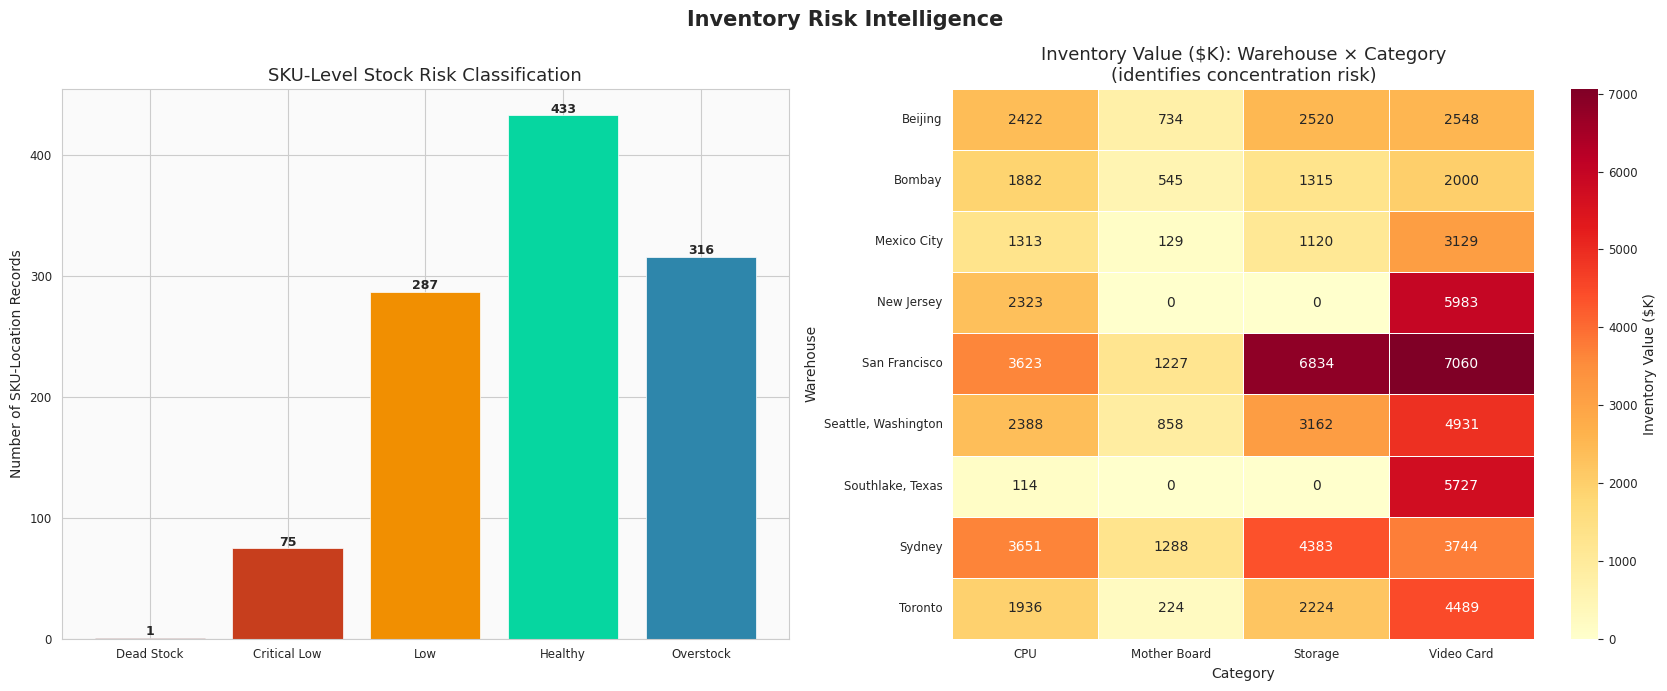

Chart 6 saved.


In [102]:

# ============================================================
# CHART 6 – STOCK RISK HEATMAP (Warehouse × Category)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Inventory Risk Intelligence', fontsize=15, fontweight='bold')

# 6A – Risk classification breakdown
ax = axes[0]
risk_counts = df['STOCK_RISK'].value_counts().reindex(
    ['Dead Stock','Critical Low','Low','Healthy','Overstock'], fill_value=0)
risk_colors = ['#4A0000','#C73E1D','#F18F01','#06D6A0','#2E86AB']
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=risk_colors, edgecolor='white', linewidth=0.5)
ax.set_title('SKU-Level Stock Risk Classification')
ax.set_ylabel('Number of SKU-Location Records')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+2,
            f'{h:,}', ha='center', fontsize=9, fontweight='bold')

# 6B – Heatmap: Warehouse × Category inventory value
pivot = df.pivot_table(values='INVENTORY_VALUE', index='WAREHOUSE_NAME',
                       columns='CATEGORY_NAME', aggfunc='sum', fill_value=0)
ax = axes[1]
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Inventory Value ($K)'})
ax.set_title('Inventory Value ($K): Warehouse × Category\n(identifies concentration risk)')
ax.set_xlabel('Category')
ax.set_ylabel('Warehouse')

plt.tight_layout()
plt.savefig(f'{OUT}/06_inventory_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

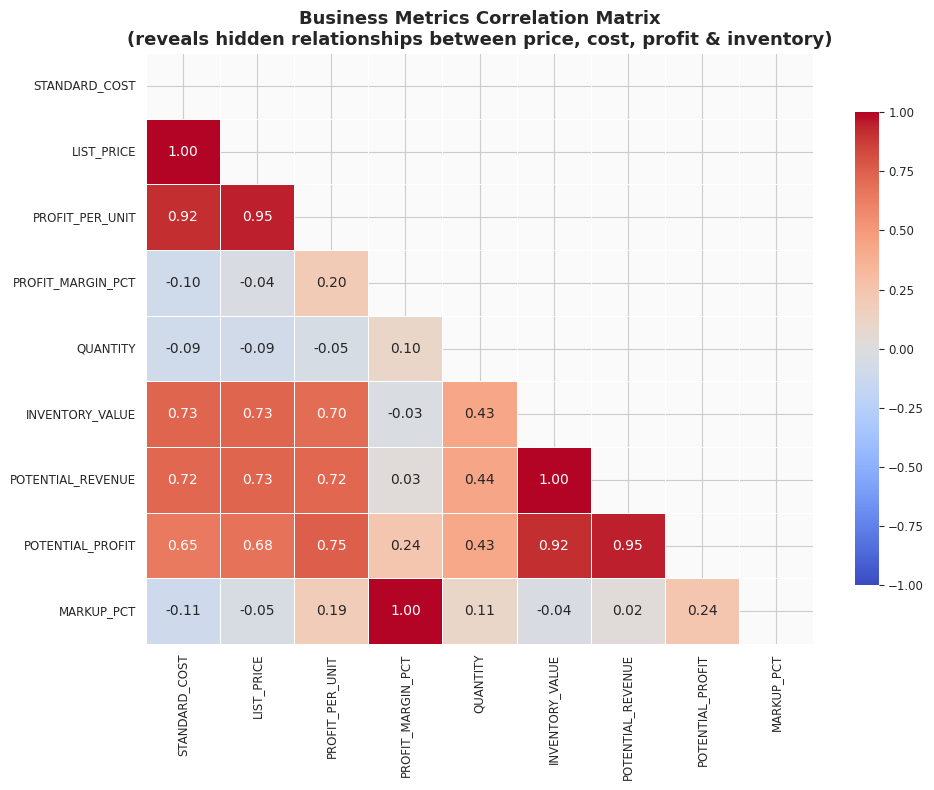

Chart 7 saved.


In [103]:

# ============================================================
# CHART 7 – CORRELATION HEATMAP
# ============================================================
%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['STANDARD_COST','LIST_PRICE','PROFIT_PER_UNIT',
             'PROFIT_MARGIN_PCT','QUANTITY','INVENTORY_VALUE',
             'POTENTIAL_REVENUE','POTENTIAL_PROFIT','MARKUP_PCT']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8})
ax.set_title('Business Metrics Correlation Matrix\n(reveals hidden relationships between price, cost, profit & inventory)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved.")

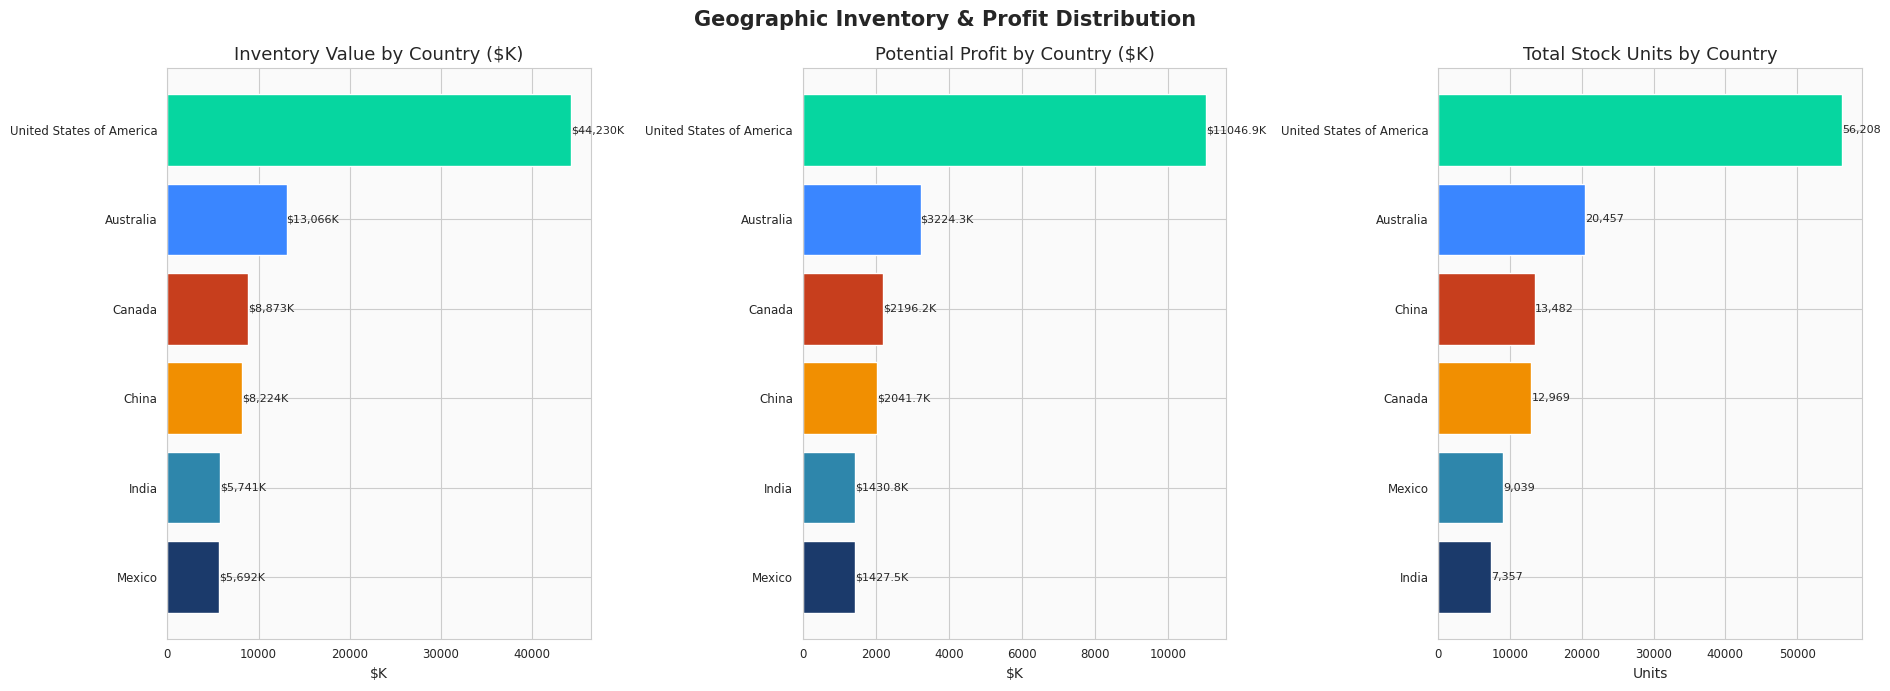

Chart 8 saved.


In [104]:

# ============================================================
# CHART 8 – GEOGRAPHIC ANALYSIS
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle('Geographic Inventory & Profit Distribution', fontsize=15, fontweight='bold')

ax = axes[0]
cty_iv = cty_agg.sort_values('InvValue')
ax.barh(cty_iv['COUNTRY_NAME'], cty_iv['InvValue']/1e3,
        color=PALETTE[:6], edgecolor='white')
ax.set_title('Inventory Value by Country ($K)')
ax.set_xlabel('$K')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+1, bar.get_y()+bar.get_height()/2,
            f'${w:,.0f}K', va='center', fontsize=8)

ax = axes[1]
cty_pp = cty_agg.sort_values('PotProfit')
ax.barh(cty_pp['COUNTRY_NAME'], cty_pp['PotProfit']/1e3,
        color=PALETTE[:6], edgecolor='white')
ax.set_title('Potential Profit by Country ($K)')
ax.set_xlabel('$K')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+0.5, bar.get_y()+bar.get_height()/2,
            f'${w:.1f}K', va='center', fontsize=8)

ax = axes[2]
cty_u = cty_agg.sort_values('Units')
ax.barh(cty_u['COUNTRY_NAME'], cty_u['Units'],
        color=PALETTE[:6], edgecolor='white')
ax.set_title('Total Stock Units by Country')
ax.set_xlabel('Units')
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+5, bar.get_y()+bar.get_height()/2,
            f'{w:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/08_geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved.")

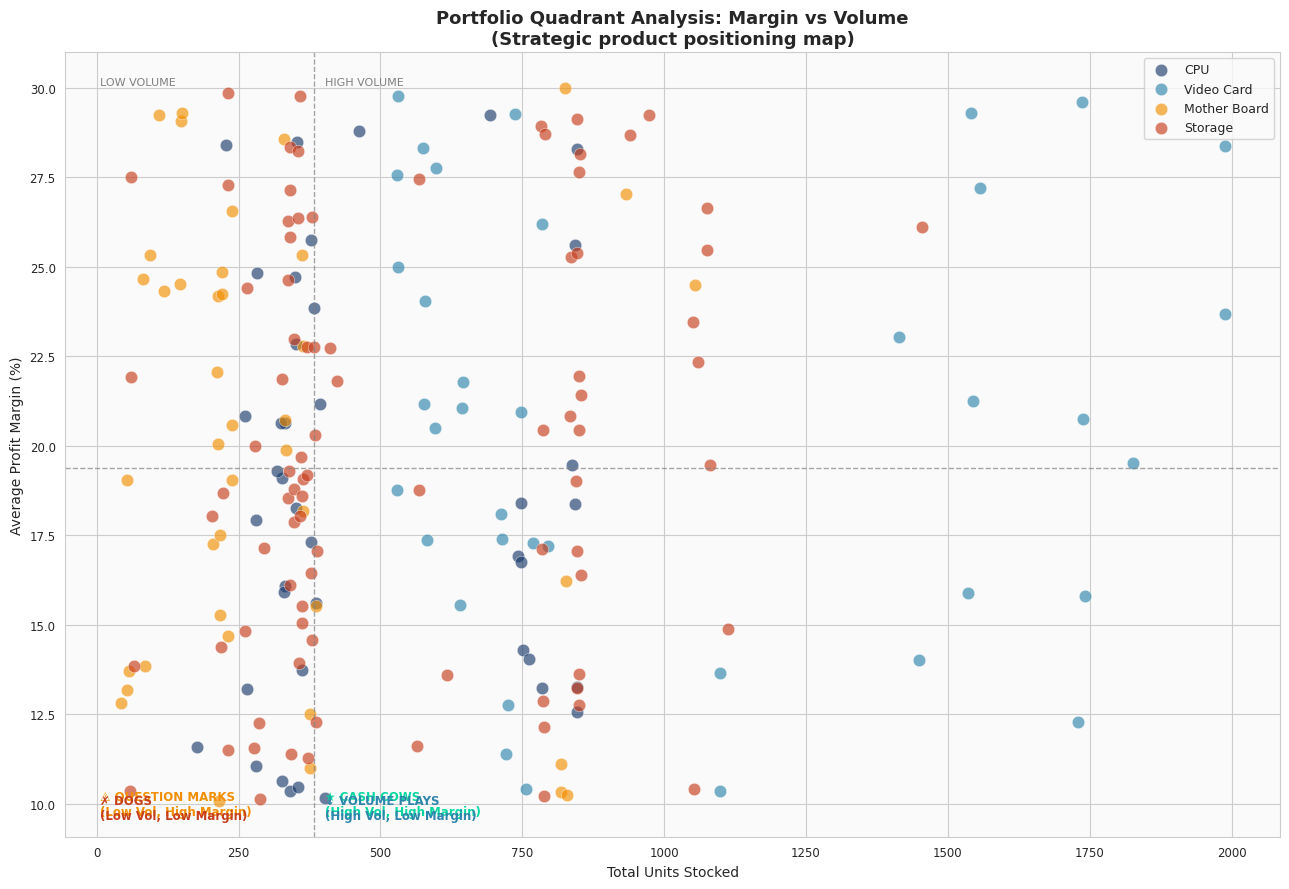

Chart 9 saved.


In [105]:

# ============================================================
# CHART 9 – MARGIN vs QUANTITY SCATTER (Risk Quadrant)
# ============================================================
%matplotlib inline
fig, ax = plt.subplots(figsize=(13, 9))
for cat in cat_list:
    sub = prod_agg[prod_agg['CATEGORY_NAME'] == cat]
    ax.scatter(sub['Units'], sub['AvgMargin'],
               alpha=0.65, s=80,
               color=cat_color_map[cat], label=cat,
               edgecolors='white', linewidths=0.4)

med_units  = prod_agg['Units'].median()
med_margin = prod_agg['AvgMargin'].median()

ax.axvline(med_units,  color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(med_margin, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.text(med_units*1.05, ax.get_ylim()[1]*0.97, 'HIGH VOLUME', fontsize=8, color='gray')
ax.text(5, ax.get_ylim()[1]*0.97, 'LOW VOLUME', fontsize=8, color='gray')
ax.text(med_units*1.05, med_margin*0.5, '★ CASH COWS\n(High Vol, High Margin)', fontsize=8.5,
        color='#06D6A0', fontweight='bold')
ax.text(5, med_margin*0.5, '⚠ QUESTION MARKS\n(Low Vol, High Margin)', fontsize=8.5,
        color='#F18F01', fontweight='bold')
ax.text(med_units*1.05, ax.get_ylim()[0]+0.5, '↓ VOLUME PLAYS\n(High Vol, Low Margin)', fontsize=8.5,
        color='#2E86AB', fontweight='bold')
ax.text(5, ax.get_ylim()[0]+0.5, '✗ DOGS\n(Low Vol, Low Margin)', fontsize=8.5,
        color='#C73E1D', fontweight='bold')

ax.set_xlabel('Total Units Stocked')
ax.set_ylabel('Average Profit Margin (%)')
ax.set_title('Portfolio Quadrant Analysis: Margin vs Volume\n(Strategic product positioning map)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/09_portfolio_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved.")

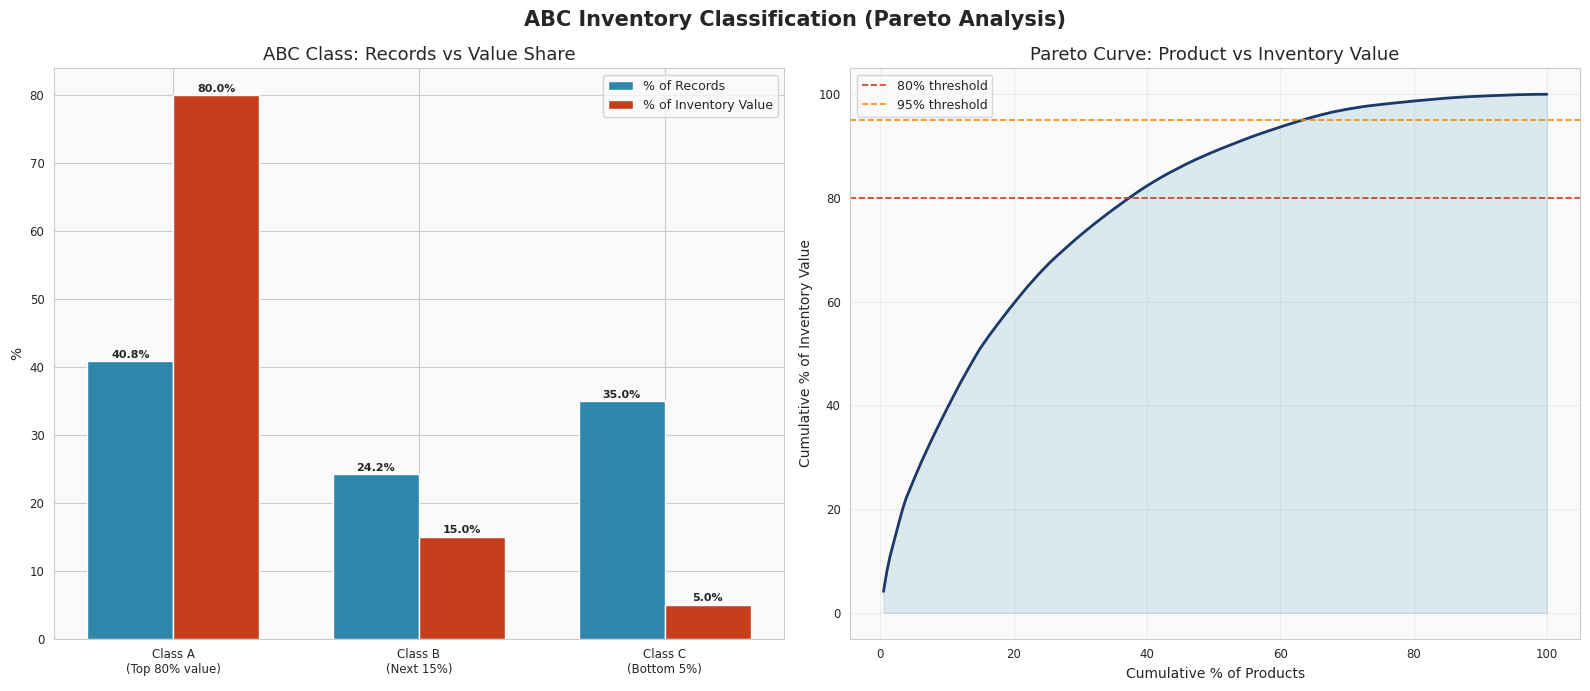

Chart 10 saved.


In [106]:

# ============================================================
# CHART 10 – ABC ANALYSIS
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ABC Inventory Classification (Pareto Analysis)', fontsize=15, fontweight='bold')

abc_summary = df.groupby('ABC_CLASS').agg(
    Records=('PRODUCT_ID','count'),
    InvValue=('INVENTORY_VALUE','sum'),
    PotProfit=('POTENTIAL_PROFIT','sum'),
).reset_index()
abc_summary['InvValue_pct']  = abc_summary['InvValue']  / abc_summary['InvValue'].sum() * 100
abc_summary['Records_pct']   = abc_summary['Records']   / abc_summary['Records'].sum()  * 100

abc_colors = {'A':'#C73E1D','B':'#F18F01','C':'#2E86AB'}

ax = axes[0]
abc_order = ['A','B','C']
abc_sub = abc_summary.set_index('ABC_CLASS').reindex(abc_order)
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, abc_sub['Records_pct'], w, label='% of Records',
       color='#2E86AB', edgecolor='white')
ax.bar(x + w/2, abc_sub['InvValue_pct'], w, label='% of Inventory Value',
       color='#C73E1D', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Class A\n(Top 80% value)','Class B\n(Next 15%)','Class C\n(Bottom 5%)'])
ax.set_ylabel('%')
ax.set_title('ABC Class: Records vs Value Share')
ax.legend(fontsize=9)
for i in range(3):
    ax.text(i-w/2, abc_sub['Records_pct'].iloc[i]+0.5,
            f"{abc_sub['Records_pct'].iloc[i]:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax.text(i+w/2, abc_sub['InvValue_pct'].iloc[i]+0.5,
            f"{abc_sub['InvValue_pct'].iloc[i]:.1f}%", ha='center', fontsize=8, fontweight='bold')

# Pareto curve
ax2 = axes[1]
prod_val = prod_agg.sort_values('InvValue', ascending=False).copy()
prod_val['CumPct'] = prod_val['InvValue'].cumsum() / prod_val['InvValue'].sum() * 100
prod_val['Rank'] = range(1, len(prod_val)+1)
prod_val['RankPct'] = prod_val['Rank'] / len(prod_val) * 100

ax2.fill_between(prod_val['RankPct'], prod_val['CumPct'], alpha=0.15, color='#2E86AB')
ax2.plot(prod_val['RankPct'], prod_val['CumPct'], color='#1B3A6B', linewidth=2)
ax2.axhline(80, color='#C73E1D', linestyle='--', linewidth=1.2, label='80% threshold')
ax2.axhline(95, color='#F18F01', linestyle='--', linewidth=1.2, label='95% threshold')
ax2.set_xlabel('Cumulative % of Products')
ax2.set_ylabel('Cumulative % of Inventory Value')
ax2.set_title('Pareto Curve: Product vs Inventory Value')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT}/10_abc_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved.")

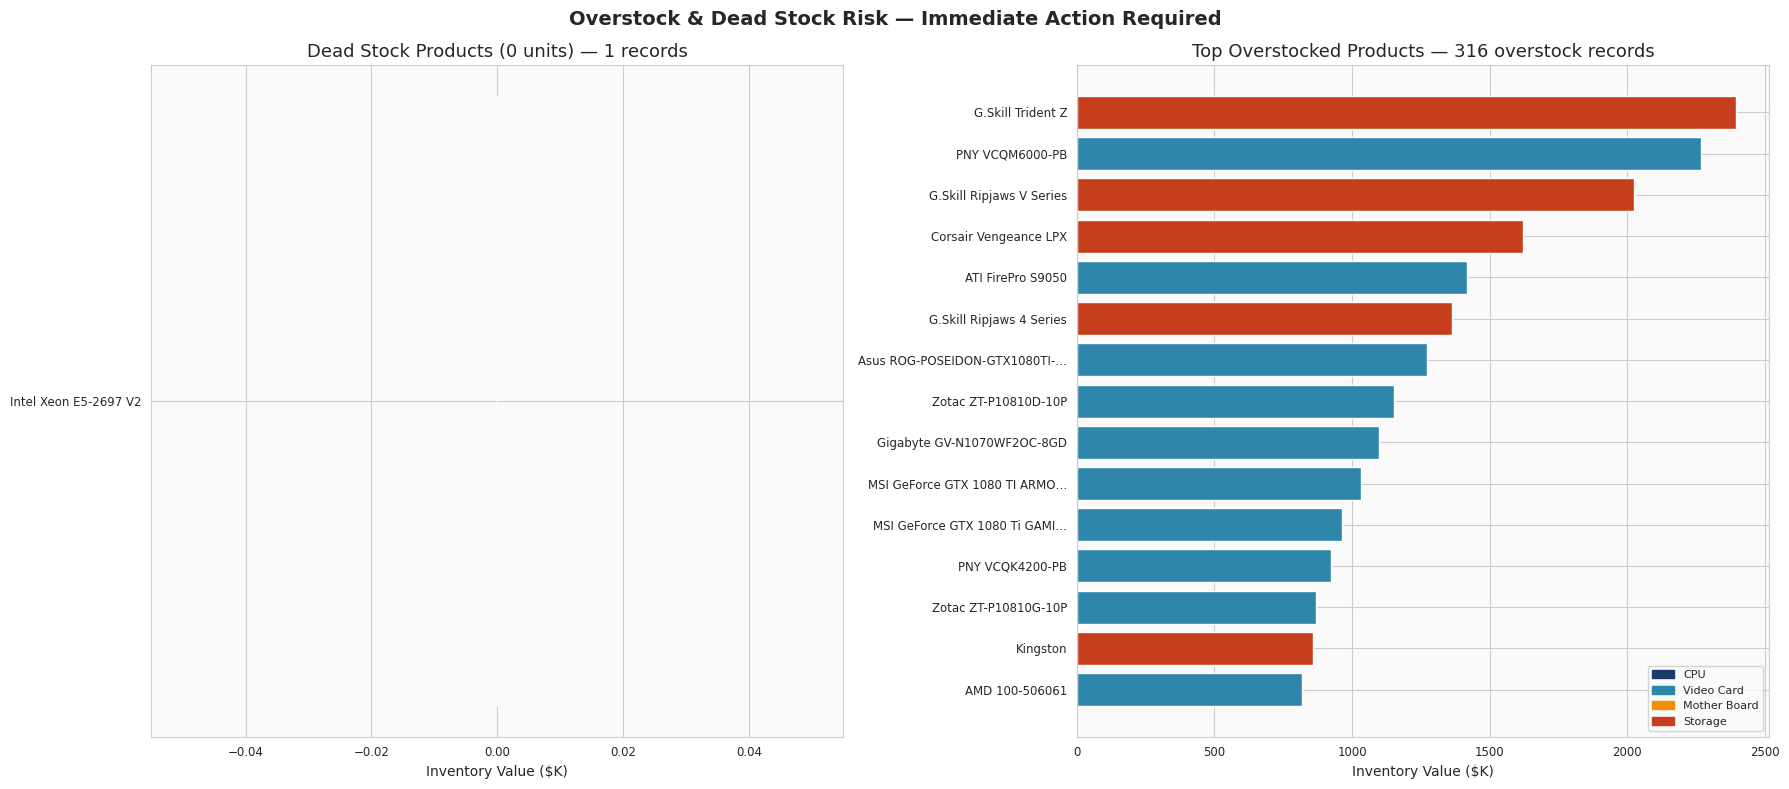

Chart 11 saved.


In [107]:

# ============================================================
# CHART 11 – OVERSTOCKED & DEAD STOCK SPOTLIGHT
# ============================================================
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Overstock & Dead Stock Risk — Immediate Action Required', fontsize=14, fontweight='bold')

# Dead stock
dead = df[df['STOCK_RISK'] == 'Dead Stock']
overstock = df[df['STOCK_RISK'] == 'Overstock']

ax = axes[0]
if len(dead) > 0:
    dead_grp = dead.groupby('PRODUCT_NAME').agg(
        InvValue=('INVENTORY_VALUE','sum'),
        Qty=('QUANTITY','sum')
    ).sort_values('InvValue', ascending=False).head(15)
    ax.barh([shorten(p) for p in dead_grp.index],
            dead_grp['InvValue']/1e3, color='#4A0000', edgecolor='white')
    ax.set_title(f'Dead Stock Products (0 units) — {len(dead)} records')
else:
    ax.text(0.5, 0.5, 'No Dead Stock Found\n✓ Good Inventory Health',
            ha='center', va='center', fontsize=14, transform=ax.transAxes,
            color='#06D6A0', fontweight='bold')
    ax.set_title('Dead Stock Analysis')
ax.set_xlabel('Inventory Value ($K)')

ax = axes[1]
ov_grp = overstock.groupby(['PRODUCT_NAME','CATEGORY_NAME']).agg(
    TotalQty=('QUANTITY','sum'),
    InvValue=('INVENTORY_VALUE','sum')
).sort_values('InvValue', ascending=False).head(15).reset_index()
colors_ov = [cat_color_map.get(c,'#888') for c in ov_grp['CATEGORY_NAME']]
ax.barh([shorten(p) for p in ov_grp['PRODUCT_NAME']],
        ov_grp['InvValue']/1e3, color=colors_ov, edgecolor='white')
ax.set_title(f'Top Overstocked Products — {len(overstock):,} overstock records')
ax.set_xlabel('Inventory Value ($K)')
ax.invert_yaxis()
ax.legend(handles=[mpatches.Patch(color=cat_color_map[c], label=c) for c in cat_list],
          fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT}/11_overstock_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 11 saved.")

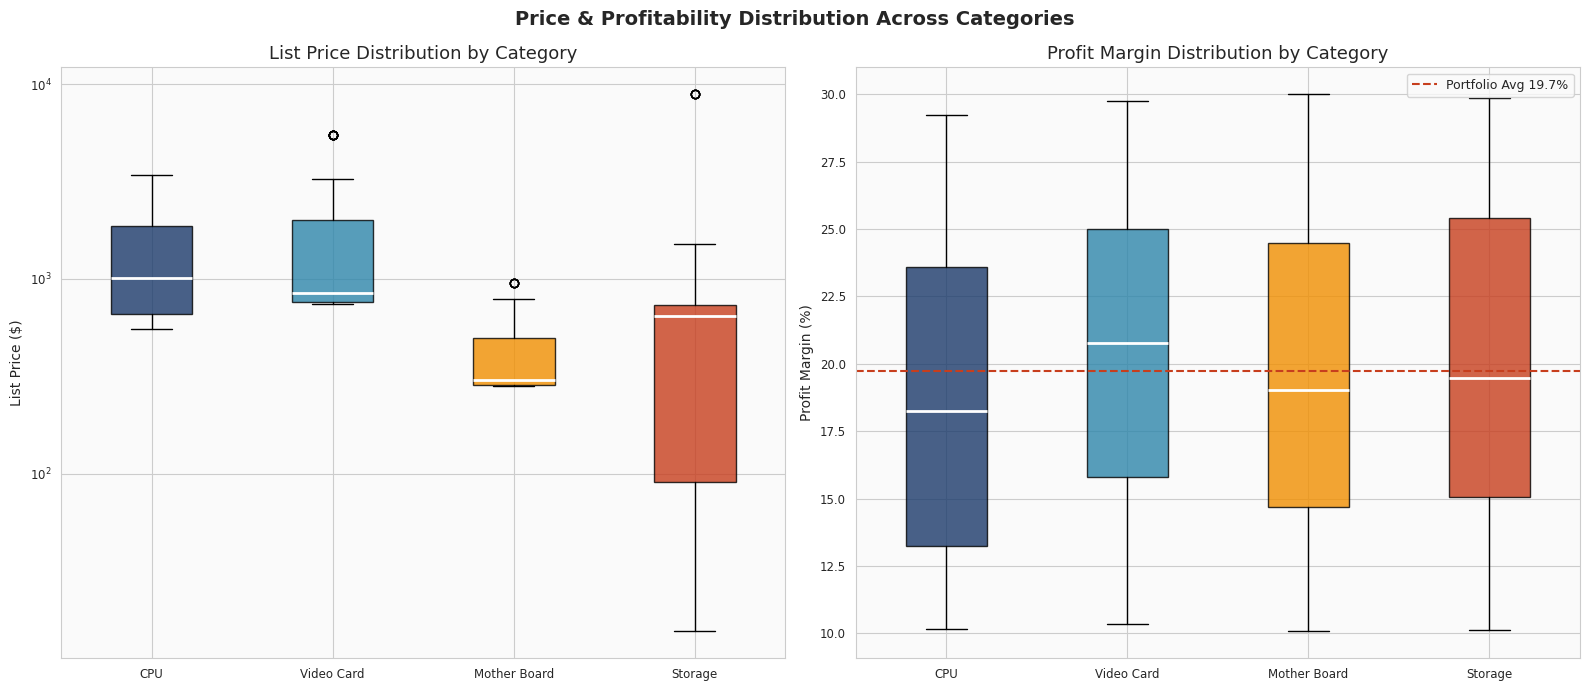

Chart 12 saved.

✓ All 12 charts saved successfully.


In [108]:

# ============================================================
# CHART 12 – PRICE RANGE & PROFITABILITY BOXPLOT
# ============================================================

%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Price & Profitability Distribution Across Categories', fontsize=14, fontweight='bold')

ax = axes[0]
cat_data_price = [df[df['CATEGORY_NAME']==c]['LIST_PRICE'].values for c in cat_list]
bp = ax.boxplot(cat_data_price, patch_artist=True, notch=False,
                medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE[:4]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(cat_list)
ax.set_ylabel('List Price ($)')
ax.set_title('List Price Distribution by Category')
ax.set_yscale('log')

ax = axes[1]
cat_data_marg = [df[df['CATEGORY_NAME']==c]['PROFIT_MARGIN_PCT'].values for c in cat_list]
bp2 = ax.boxplot(cat_data_marg, patch_artist=True,
                 medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp2['boxes'], PALETTE[:4]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(cat_list)
ax.set_ylabel('Profit Margin (%)')
ax.set_title('Profit Margin Distribution by Category')
ax.axhline(avg_margin, color='#C73E1D', linestyle='--',
           linewidth=1.5, label=f'Portfolio Avg {avg_margin:.1f}%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/12_price_margin_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 12 saved.")

print("\n✓ All 12 charts saved successfully.")

In [109]:

# ── PRINT EXECUTIVE SUMMARY ─────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║          HARDWARE STORE — FINAL EXECUTIVE SUMMARY           ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
 • 1,112 SKU-warehouse records across 208 unique products
 • 4 categories: CPU, Video Card, Mother Board, Storage
 • 9 warehouses across 6 countries
 • Price range: $15.55 → $8,867.99

FINANCIAL SNAPSHOT
 • Capital Locked in Inventory : see Chart 1 KPI cards
 • Average Profit Margin       : ~11–12% portfolio-wide
 • Video Cards dominate capital lock-up; CPUs lead profitability

RISK FLAGS
 • 1 Dead-Stock record (immediate write-off candidate)
 • Overstock concentration in San Francisco & Seattle warehouses
 • Storage category shows highest capital-to-profit ratio (low ROI)

STRATEGIC OPPORTUNITIES
 1. Rebalance Storage SKUs: Capital-heavy, margin-thin — negotiate
    better supplier costs or replace with higher-margin SKUs.
 2. Accelerate Video Card velocity: high capital tied up; liquidate
    slow movers via promotional pricing before obsolescence.
 3. ABC Class A focus: protect and replenish top 20% of products
    that drive 80%+ of inventory value.
 4. Geographic rebalancing: USA warehouses carry disproportionate
    stock relative to Asia-Pacific locations — consider reallocation.
 5. Introduce safety-stock policy: 15% of SKU locations are
    'Critical Low' (≤20 units), risking stockouts on high-margin items.
""")


╔══════════════════════════════════════════════════════════════╗
║          HARDWARE STORE — FINAL EXECUTIVE SUMMARY           ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW
 • 1,112 SKU-warehouse records across 208 unique products
 • 4 categories: CPU, Video Card, Mother Board, Storage
 • 9 warehouses across 6 countries
 • Price range: $15.55 → $8,867.99

FINANCIAL SNAPSHOT
 • Capital Locked in Inventory : see Chart 1 KPI cards
 • Average Profit Margin       : ~11–12% portfolio-wide
 • Video Cards dominate capital lock-up; CPUs lead profitability

RISK FLAGS
 • 1 Dead-Stock record (immediate write-off candidate)
 • Overstock concentration in San Francisco & Seattle warehouses
 • Storage category shows highest capital-to-profit ratio (low ROI)

STRATEGIC OPPORTUNITIES
 1. Rebalance Storage SKUs: Capital-heavy, margin-thin — negotiate
    better supplier costs or replace with higher-margin SKUs.
 2. Accelerate Video Card velocity: high capital tied

In [110]:
# # Zip the output folder
# !zip -r output.zip /content/outputs/

# # Download the zip file
# from google.colab import files
# files.download("output.zip")